In [1]:
import jax

jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_platform_name", "gpu")
print(jax.local_devices()[0].device_kind)

import os
import zodiax as zdx
from zodiax.optimisation import sgd, adam
from jax import numpy as np, random as jr, tree as jtu
from scipy.ndimage import binary_dilation

# import dLux.utils as dlu

import amigo
import dorito

# import astropy

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl


# import ehtplot
# import scienceplots
# import cmasher as cmr

# matplotlib parameters
# plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

NVIDIA GeForce RTX 2080 Ti


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    morgana = "/media/morgana1/"
else:
    morgana = "/Volumes/morgana1/"

data_path = os.path.join(morgana, "snert/max/data/JWST/WR137/calslope/")
uncal_path = os.path.join(morgana, "snert/max/data/JWST/WR137/uncal/")
amigo_cache = os.path.join(morgana, "snert/max/data/amigo_files/")

cache = os.path.join(amigo_cache, "cal_files/")
output_path = os.path.join(amigo_cache, "outputs/WR137/")

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    # "F430M",
    "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

# Loading in data

In [3]:
files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)
# nsci = 1; ncal = 4
rolls = {}
sci_files = []
cal_files = []

for file in files:

    filename = file[0].header["FILENAME"].replace("_nis_calslope.fits", "")
    rolls[filename] = dorito.plotting.calc_parang(file)

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[35, 70] = 1
    file["BADPIX"].data[70, 55] = 1
    file["BADPIX"].data[5, 5] = 1
    file["BADPIX"].data[-4, 37] = 1
    file["BADPIX"].data[51, 27] = 1
    file["BADPIX"].data[28, 18] = 1
    file["BADPIX"].data[32, 10] = 1

    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1
    # file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
    # file["BADPIX"].data[40, 45] = 1  # MIDDLE PIXELS

    # badpix = np.array(file["BADPIX"].data, dtype=bool)
    # im = np.array(file["SLOPE"].data.sum(0))
    # im = np.where(badpix, np.nan, im)
    # mask = binary_dilation(im == np.nanmax(im), iterations=2)
    # file["BADPIX"].data += mask.astype(int)

    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        file[0].header["TARGPROP"] = "HD 228337"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

In [4]:
from astropy.time import Time

t0 = Time(0, format="mjd")
for file in files:
    h = file[0].header
    t = Time(h["EXPMID"], format="mjd")

    if t.ymdhms[2] != t0.ymdhms[2]:
        print("\n" + 30 * "-" + "\n")

    print(
        f'{h["TARGPROP"]} {h["FILTER"]}, Dither {h["PATT_NUM"]}/{h["NUMDTHPT"]}, Roll {h["ROLL_REF"]:.1f}deg, {h["XPOSURE"] / 60:.1f}min, {t.iso}'
    )

    t0 = t

# h


------------------------------

WR137 F480M, Dither 1/4, Roll 192.0deg, 2.0min, 2022-07-13 11:42:10.194
WR137 F480M, Dither 2/4, Roll 192.0deg, 2.0min, 2022-07-13 11:46:01.618
WR137 F480M, Dither 3/4, Roll 192.0deg, 2.0min, 2022-07-13 11:49:54.065
WR137 F480M, Dither 4/4, Roll 192.0deg, 2.0min, 2022-07-13 11:53:45.553
WR137 F380M, Dither 1/4, Roll 192.0deg, 1.7min, 2022-07-13 11:58:59.820
WR137 F380M, Dither 2/4, Roll 192.0deg, 1.7min, 2022-07-13 12:03:02.507
WR137 F380M, Dither 4/4, Roll 192.0deg, 1.7min, 2022-07-13 12:11:07.947

------------------------------

HD 228337 F480M, Dither 1/1, Roll 189.5deg, 9.0min, 2022-07-15 11:42:00.230
HD 228337 F380M, Dither 1/1, Roll 189.5deg, 6.8min, 2022-07-15 11:54:31.525
WR137 F480M, Dither 1/4, Roll 189.8deg, 8.0min, 2022-07-15 12:38:42.741
WR137 F380M, Dither 1/4, Roll 189.8deg, 6.8min, 2022-07-15 12:51:09.154

------------------------------

WR137 F480M, Dither 1/4, Roll 162.7deg, 2.0min, 2022-08-08 18:44:08.571
WR137 F480M, Dither 2/4, Roll

/media/data/max/anaconda3/envs/ami/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [5]:
class DitherAbVisFit(amigo.model_fits.SplineVisFit):

    date: str  # isot
    month: str

    def __init__(self, file, joint_fit=False):
        expmid = Time(file[0].header["EXPMID"], format="mjd")
        self.date = str(expmid.isot)
        self.month = f"{expmid.ymdhms[1]:02d}"
        super().__init__(file, joint_fit=joint_fit)

    # def get_key(self, param):
    #     # Return the per exposure key if not joint fitting
    #     match param:
    #         case "aberrations":

    #             dither = "S" if self.month == "07" else self.dither

    #             return "_".join(
    #                 [
    #                     self.program,
    #                     self.filter,
    #                     dither,
    #                     self.month,
    #                 ]
    #             )

    #     return super().get_key(param)

    def print_summary(self):
        print(
            # f"File {self.key}\n"
            f"Star {self.star}\n"
            f"Filter {self.filter}\n"
            f"Parang {self.parang:.2f} deg\n"
            f"Dither {self.dither}\n"
            f"Date {self.date}\n"
            # f"nints {self.nints}\n"
            # f"ngroups {len(self.slopes)+1}\n"
        )

In [ ]:
load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()

cal_exposures = [DitherAbVisFit(file) for file in cal_files]
sci_exposures = [DitherAbVisFit(file) for file in sci_files]
exposures = cal_exposures + sci_exposures
# exposures = cal_exposures[0:3] + [sci_exposures[i] for i in [0, 1, 4, 5, 6]]
# exposures = [cal_exposures[i] for i in [0, 1]]

model = amigo.core_models.AmigoModel(
    exposures,
    optics=amigo.optical_models.AMIOptics(),
    detector=amigo.detector_models.SUB80Detector(),
    read=amigo.read_models.ReadModel(),
    vis_model=amigo.vis_models.LogVisModel(
        load_dict(cache + "vis_basis.npy"), n_basis=420
    ),
    state=load_dict(cache + "cal_model.npy"),
)

01349_F480M
Star HD 228337
Filter F480M
Parang 189.54 deg
Dither 1
Date 2022-07-15T11:42:00.230



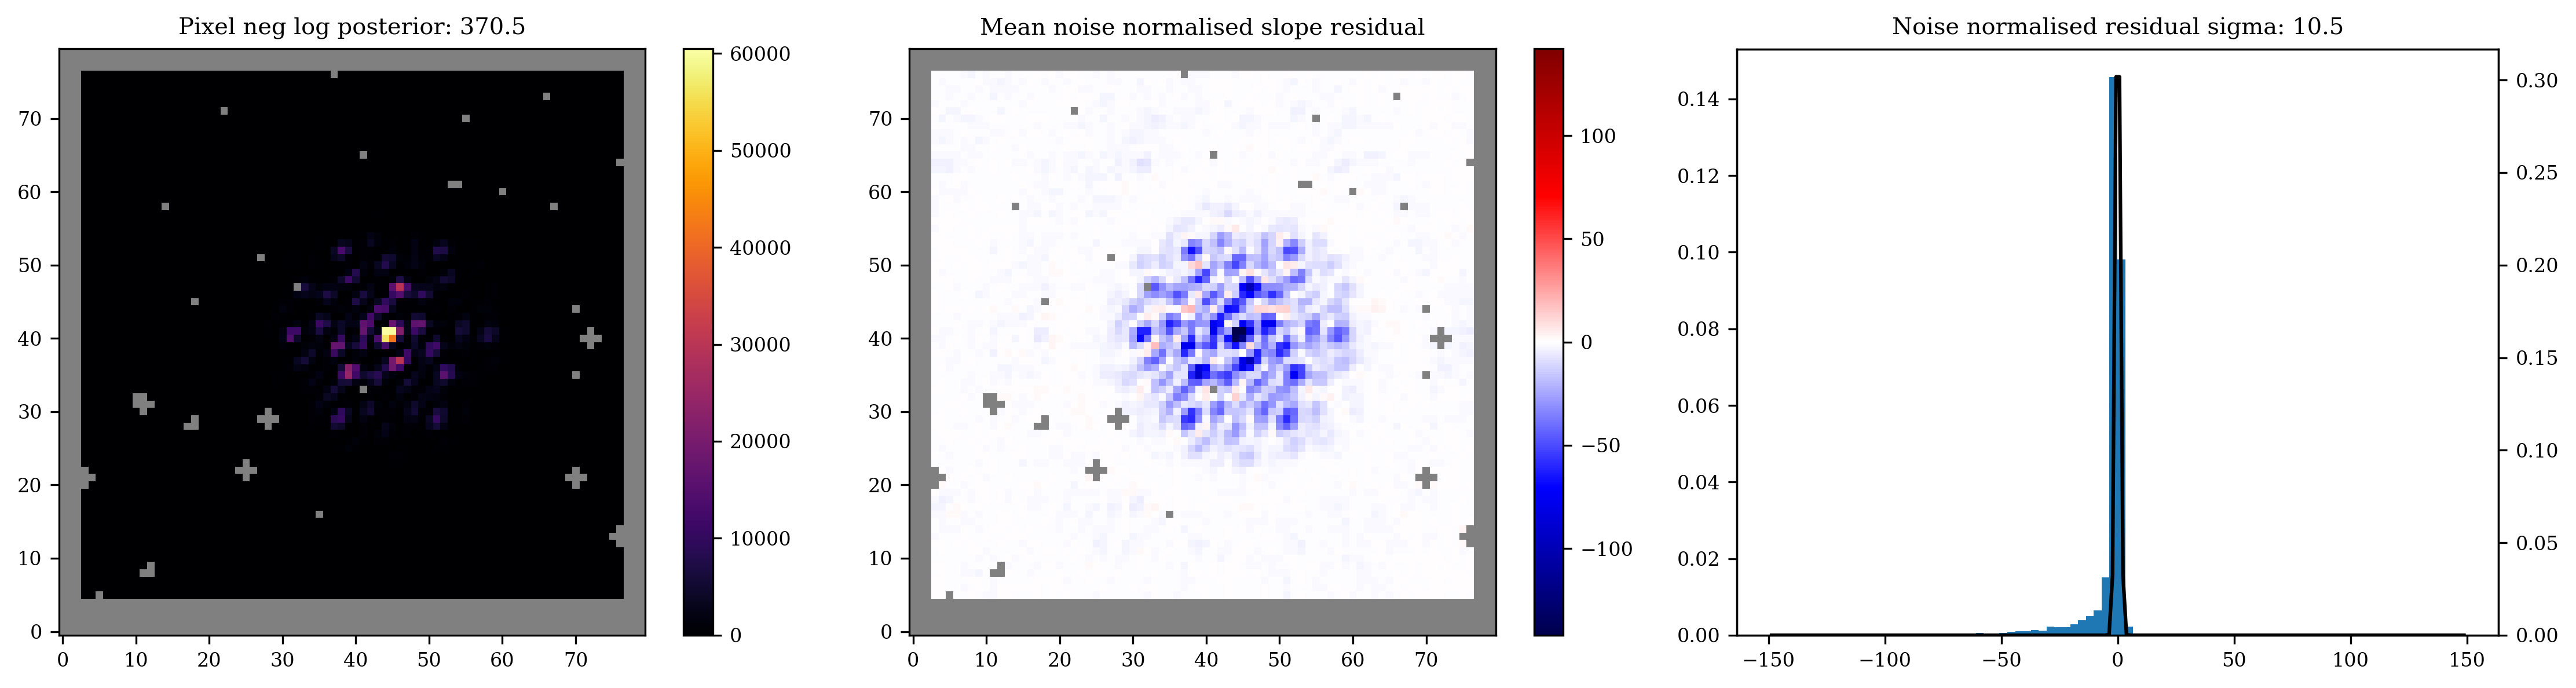

01349_F380M
Star HD 228337
Filter F380M
Parang 189.54 deg
Dither 1
Date 2022-07-15T11:54:31.525



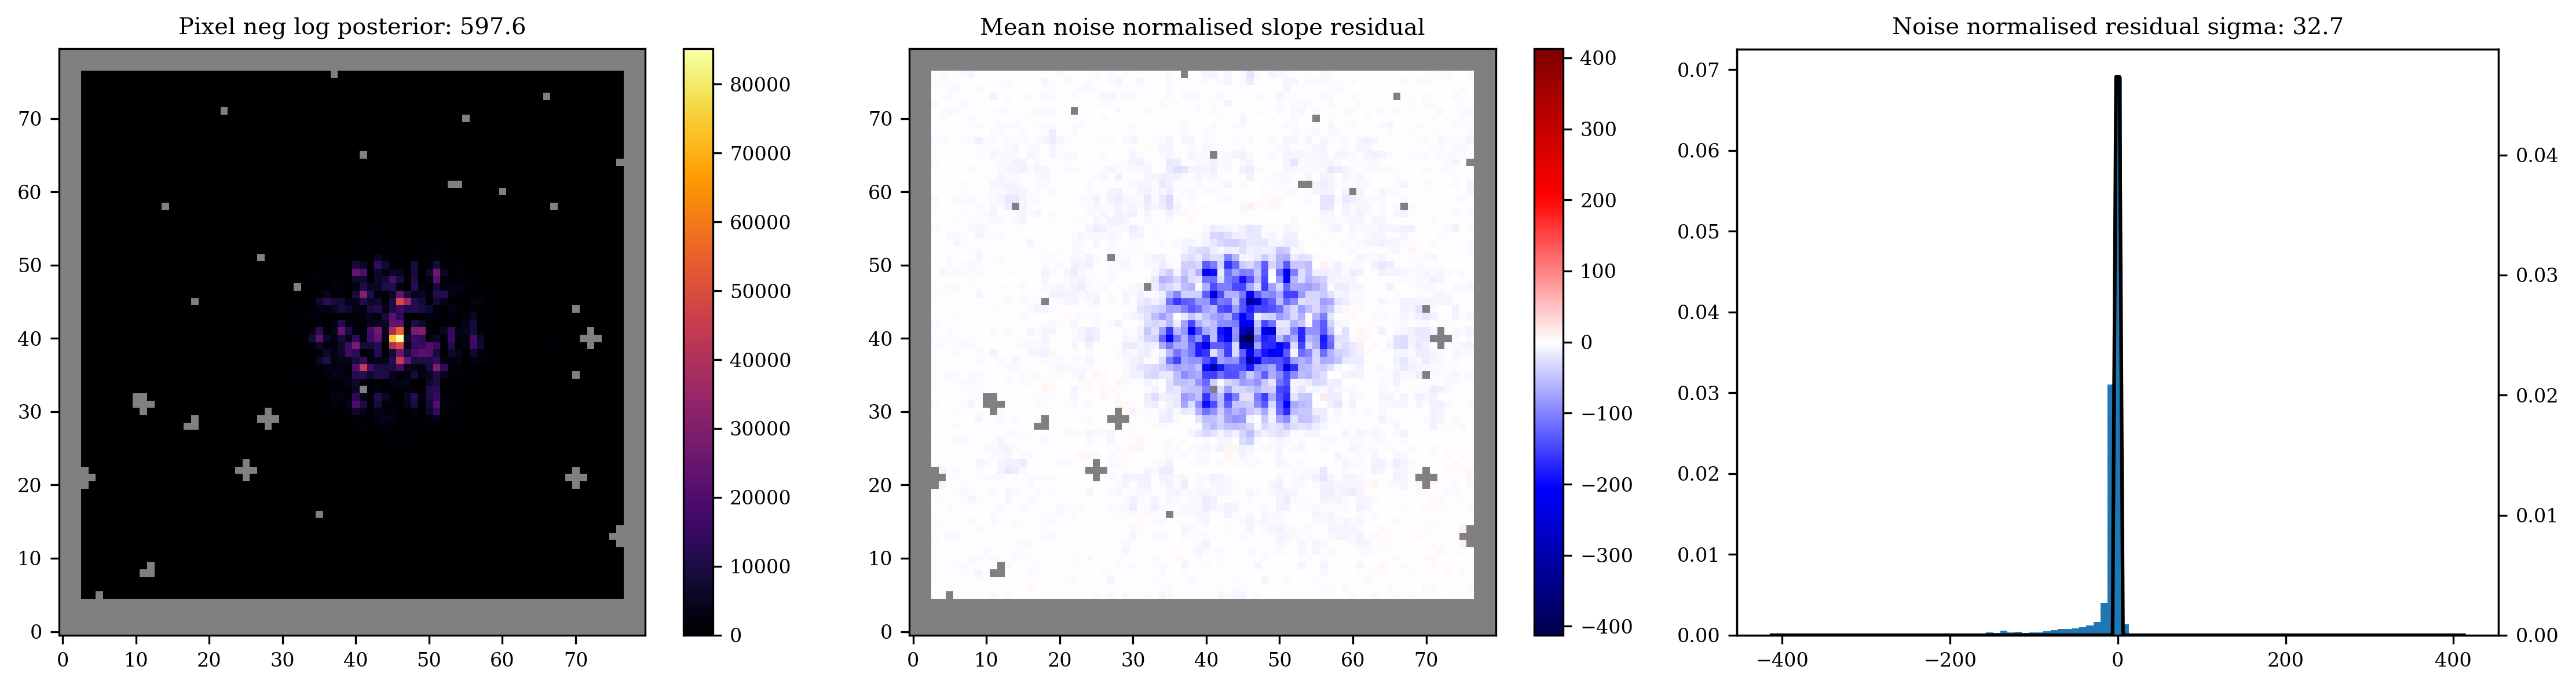

01349_F480M
Star HD 228337
Filter F480M
Parang 162.00 deg
Dither 1
Date 2022-08-08T19:49:27.954



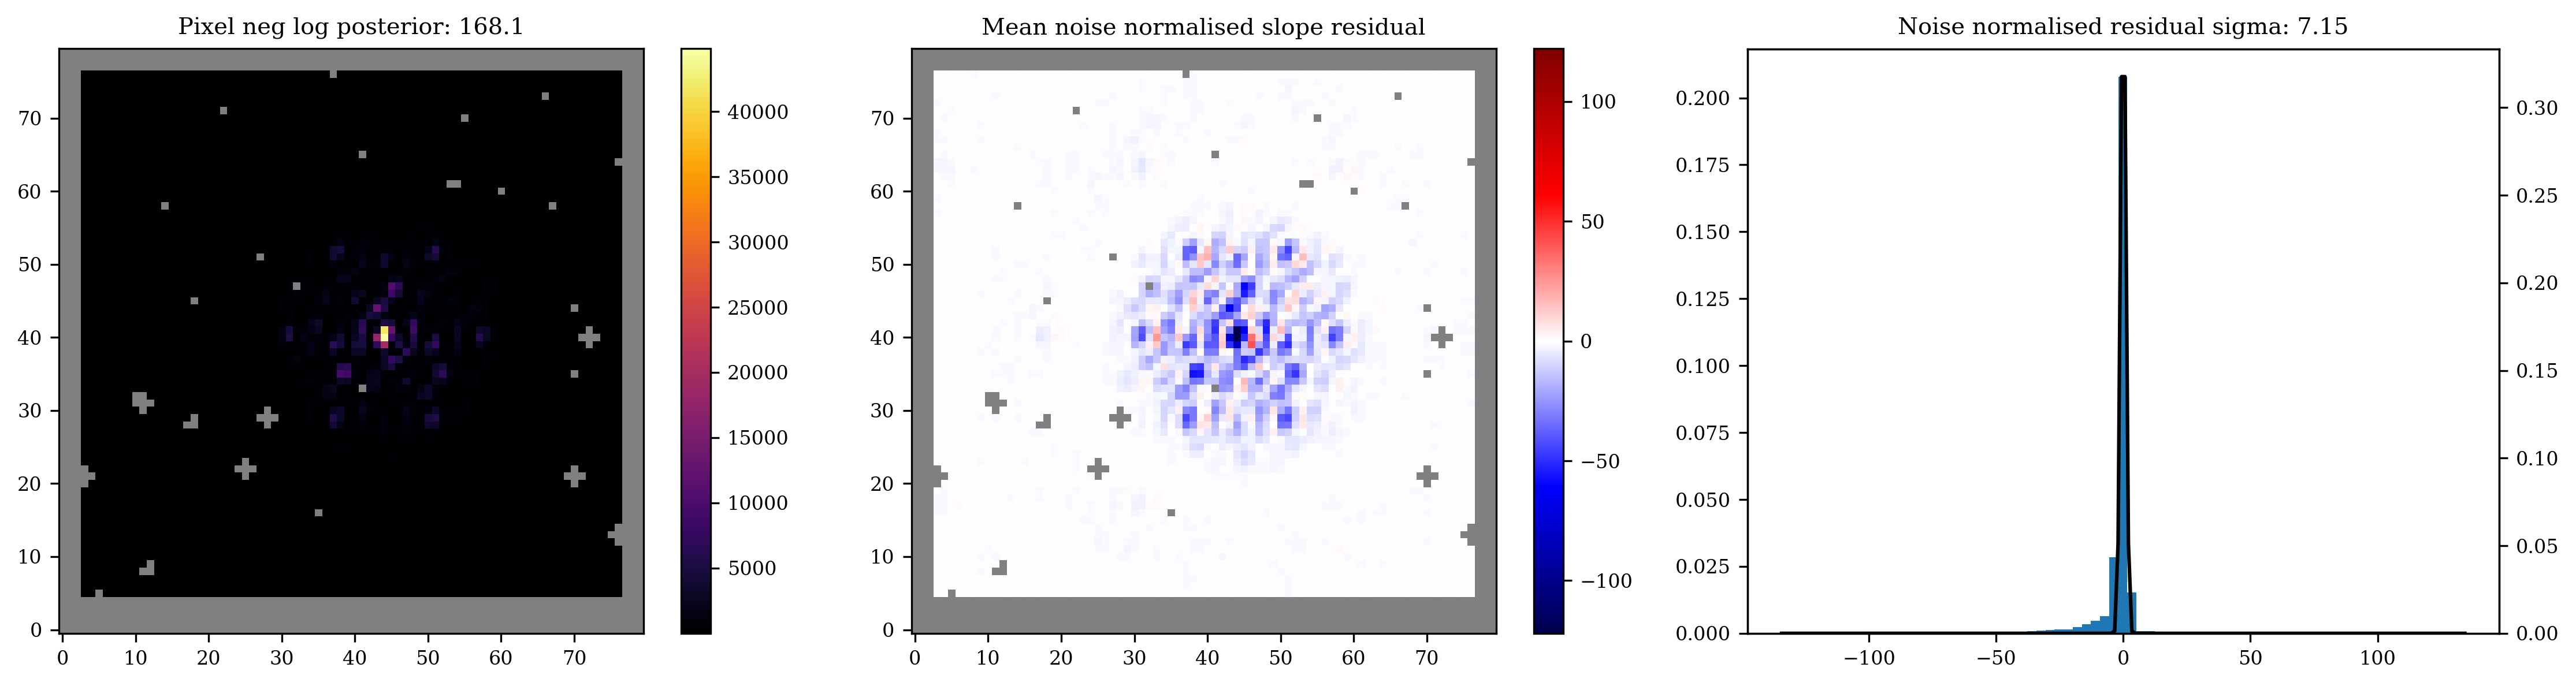

01349_F480M
Star HD 228337
Filter F480M
Parang 162.00 deg
Dither 2
Date 2022-08-08T19:53:19.378



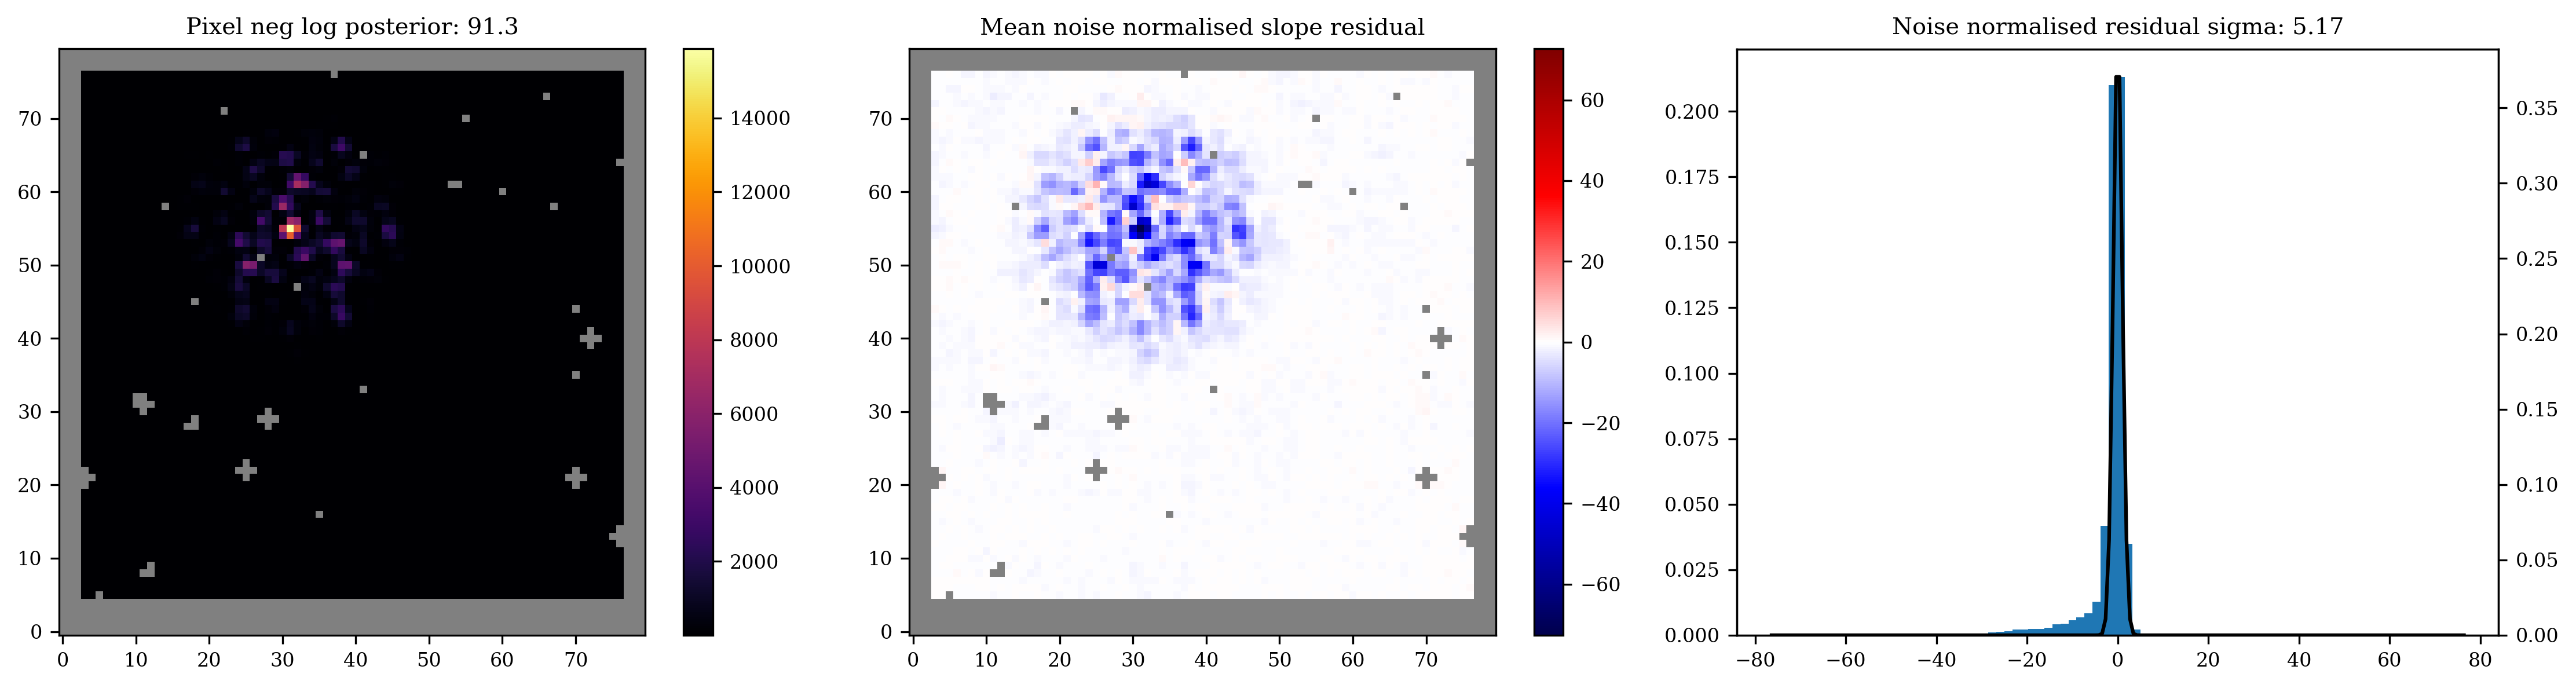

01349_F480M
Star HD 228337
Filter F480M
Parang 162.00 deg
Dither 3
Date 2022-08-08T19:57:11.826



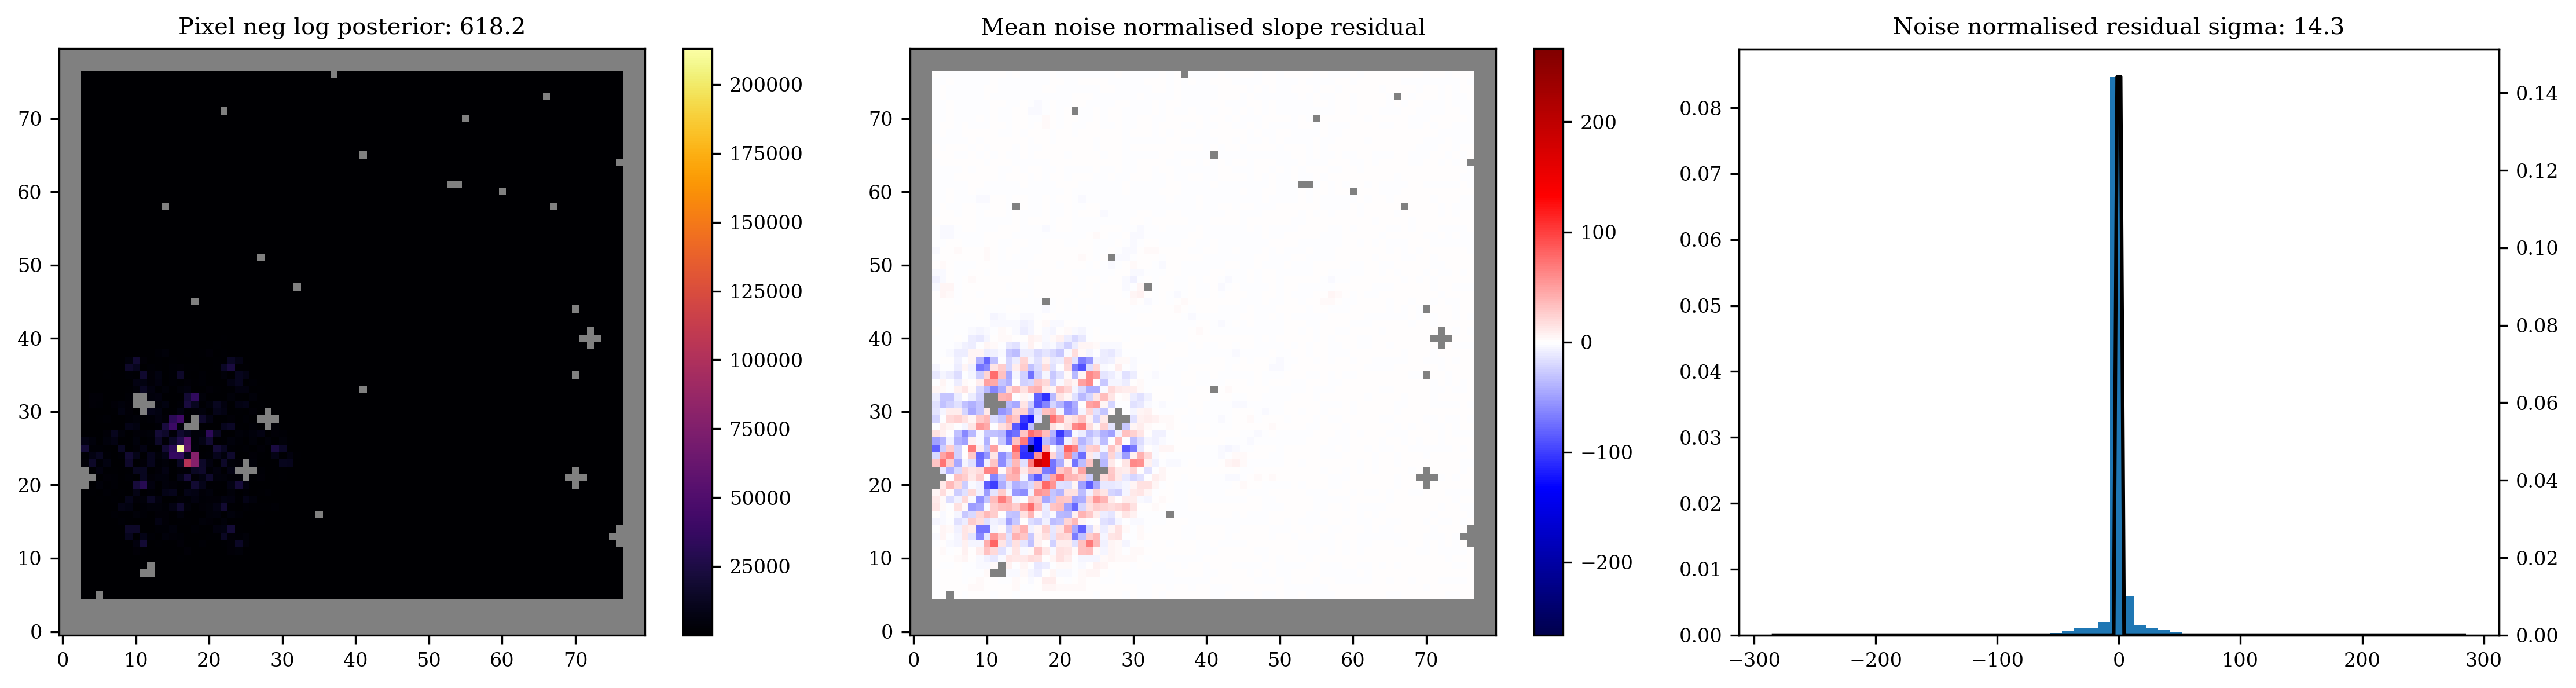

01349_F480M
Star HD 228337
Filter F480M
Parang 162.00 deg
Dither 4
Date 2022-08-08T20:01:03.250



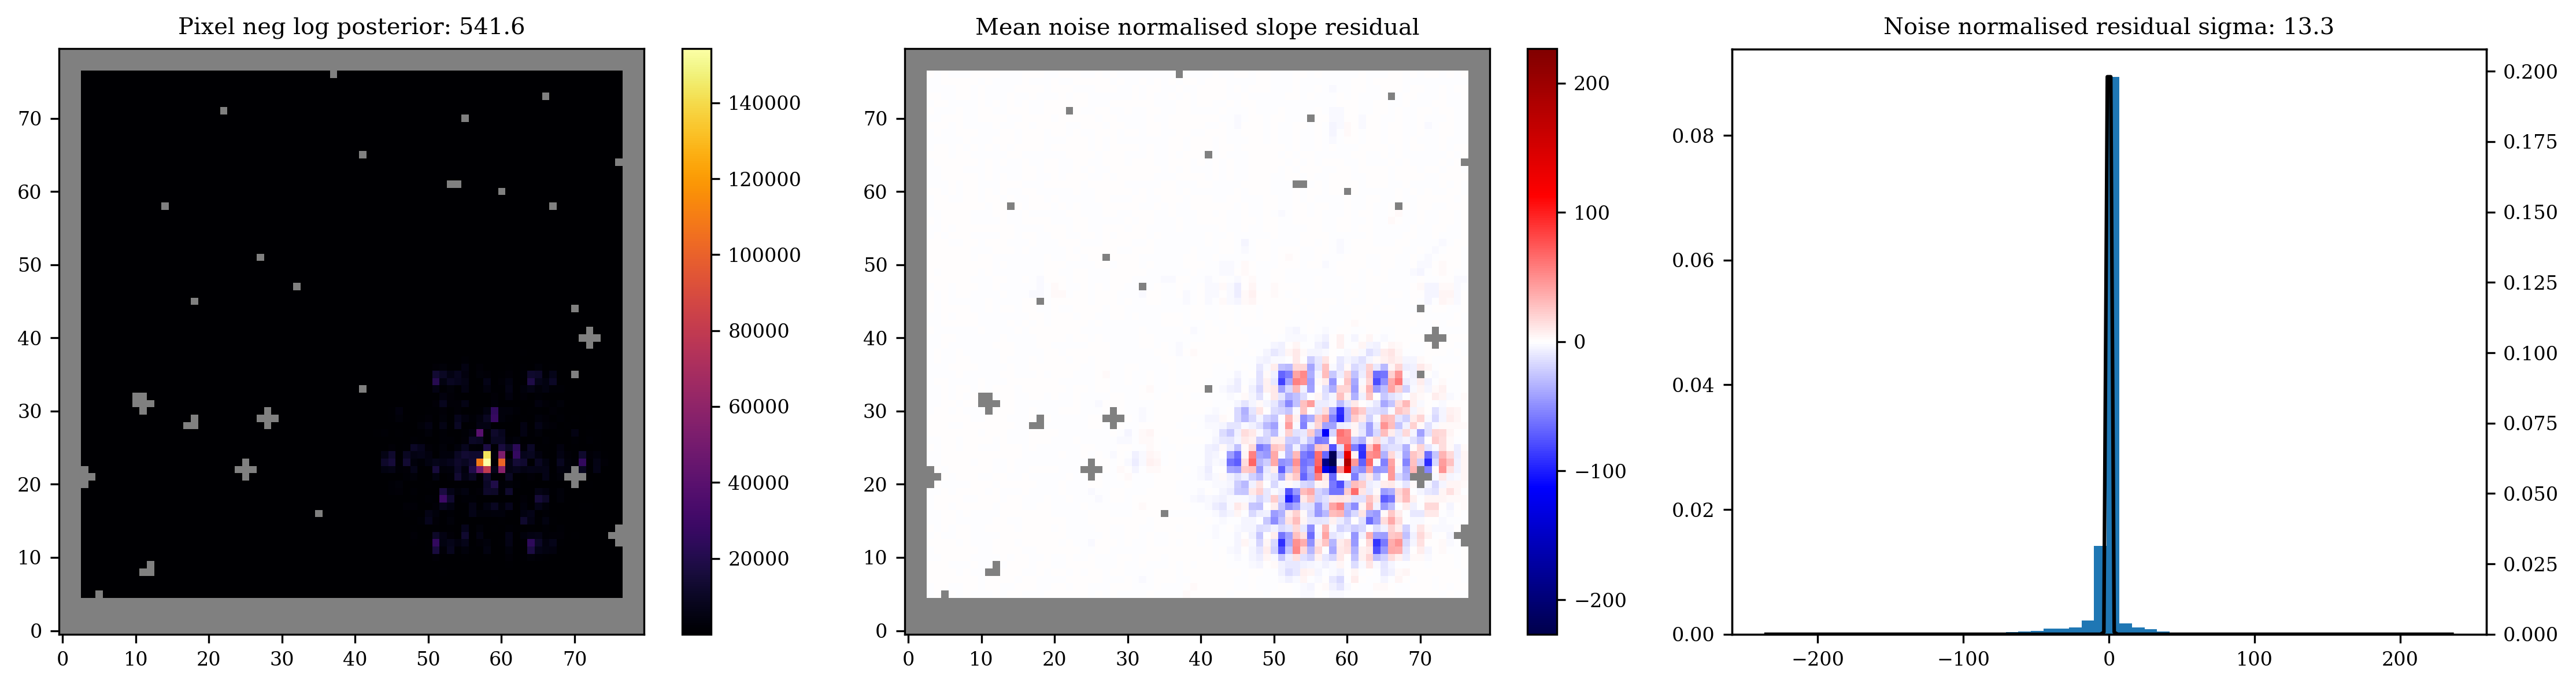

01349_F380M
Star HD 228337
Filter F380M
Parang 162.00 deg
Dither 1
Date 2022-08-08T20:06:31.377



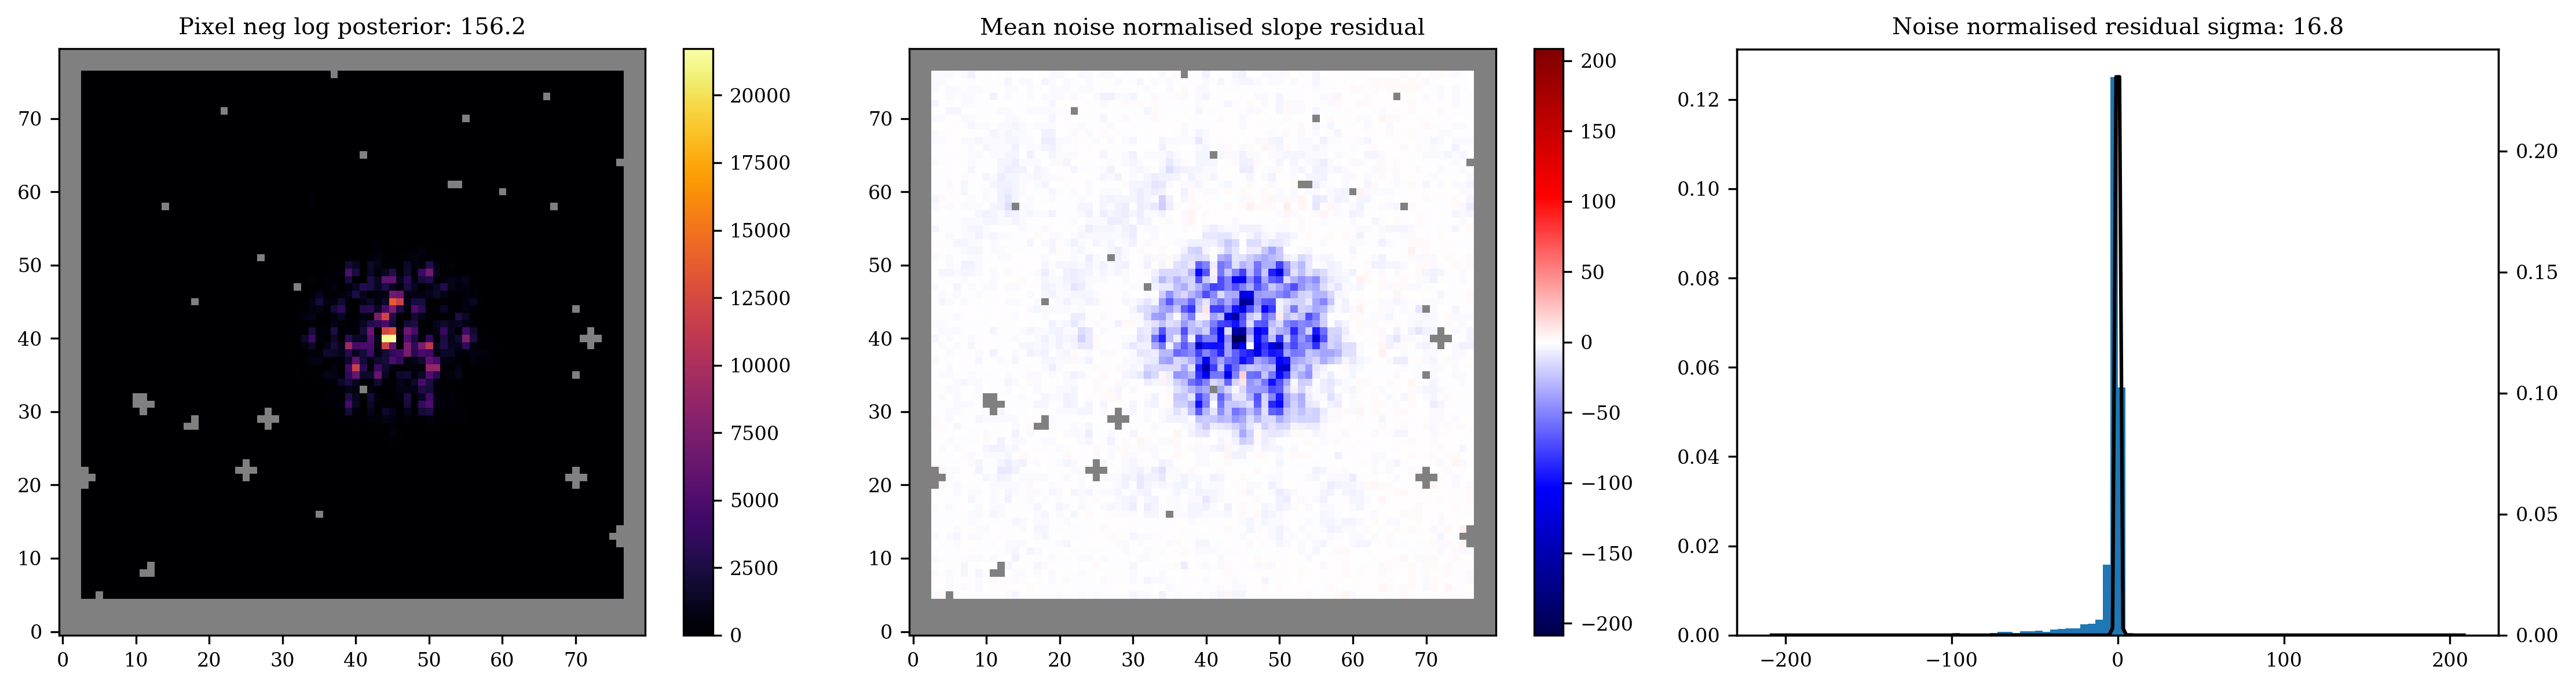

01349_F380M
Star HD 228337
Filter F380M
Parang 162.00 deg
Dither 2
Date 2022-08-08T20:10:33.041



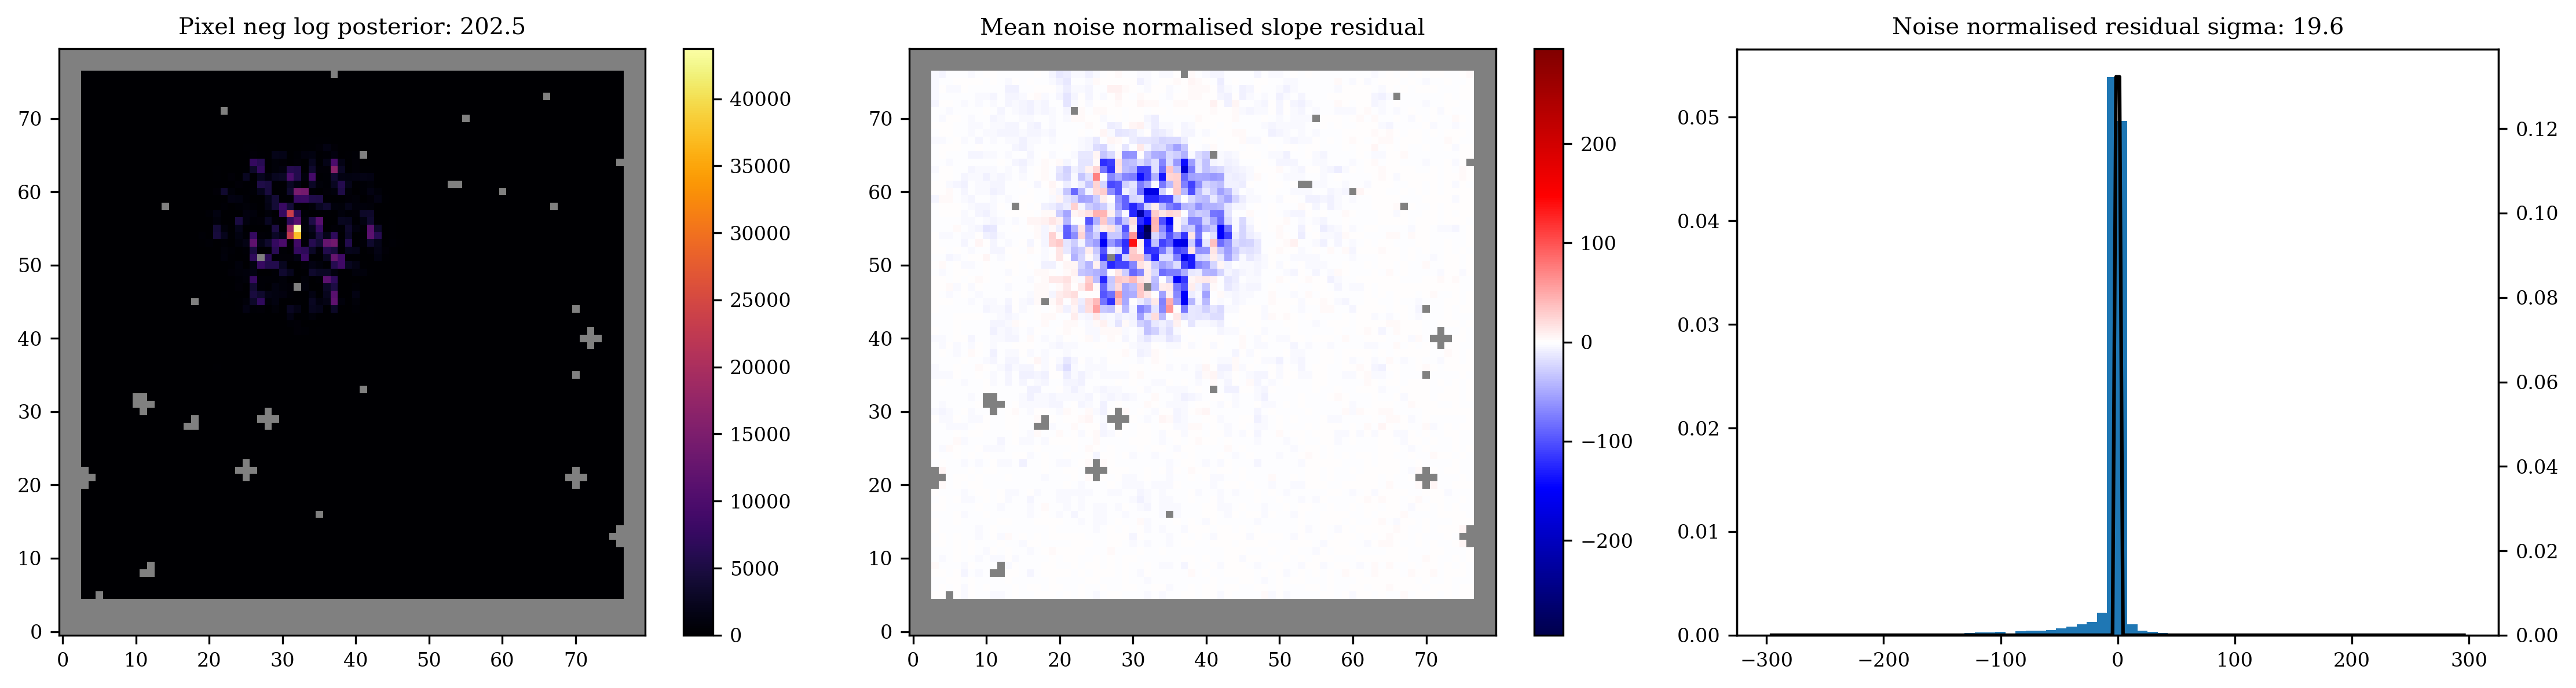

01349_F380M
Star HD 228337
Filter F380M
Parang 162.00 deg
Dither 3
Date 2022-08-08T20:14:35.729



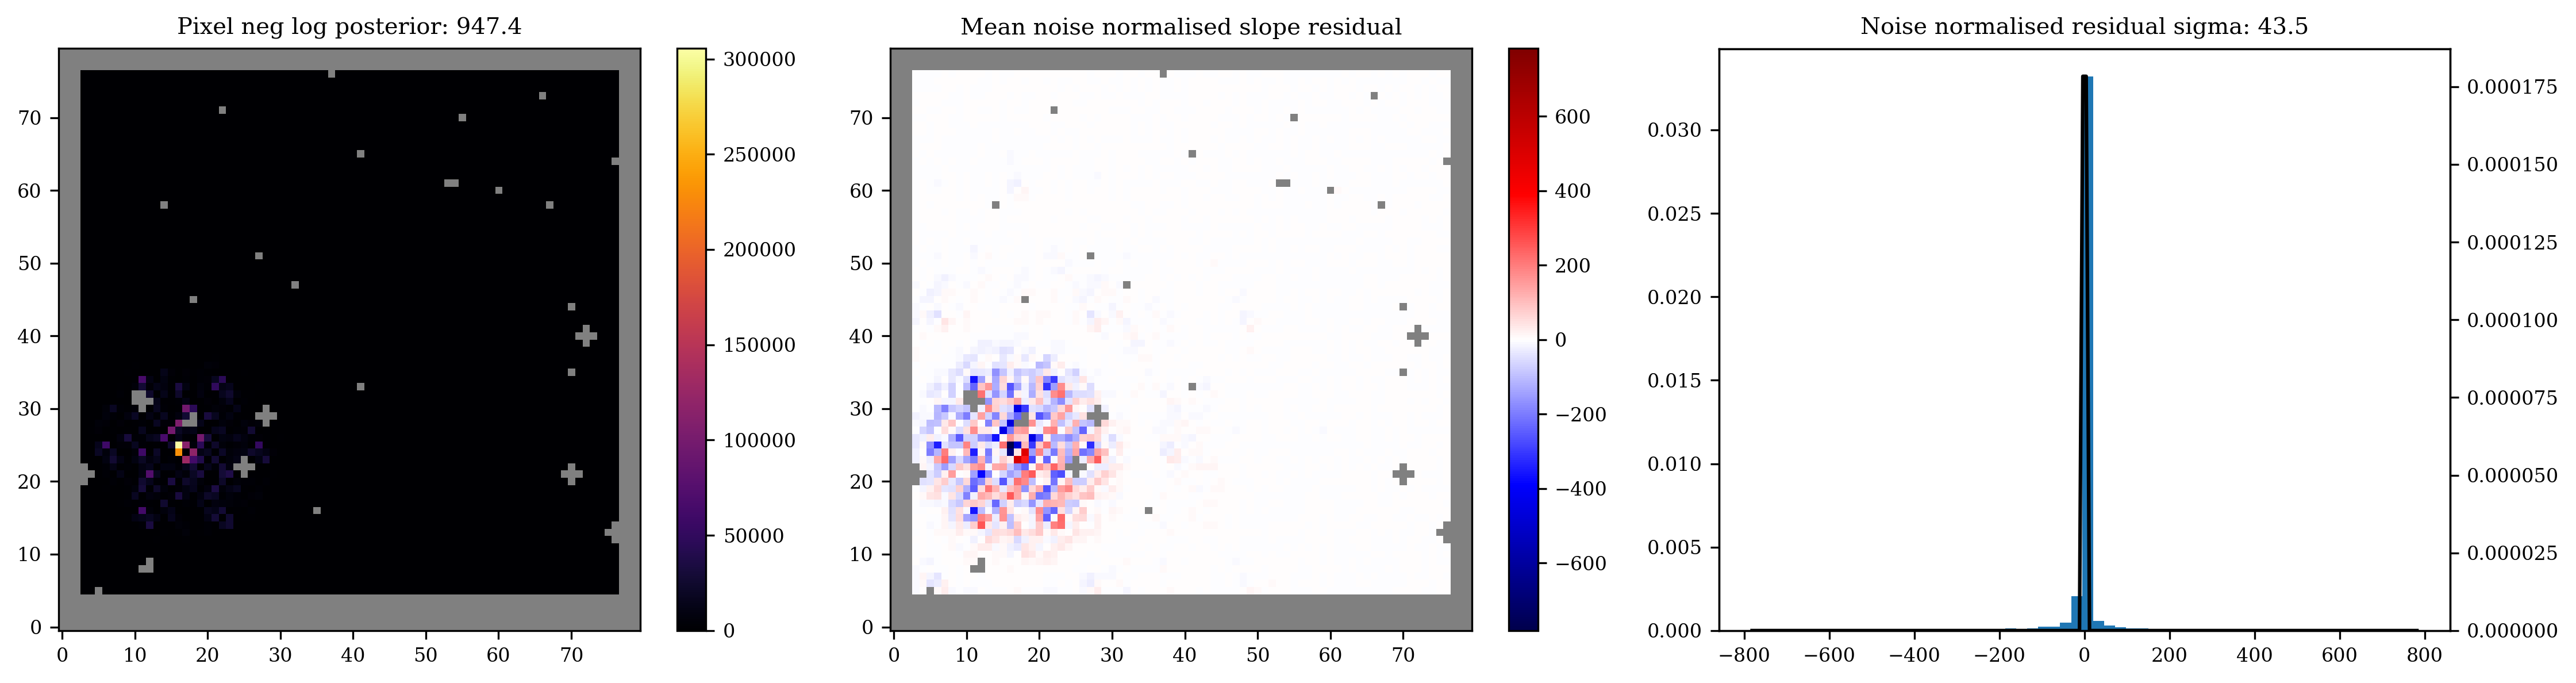

01349_F380M
Star HD 228337
Filter F380M
Parang 162.00 deg
Dither 4
Date 2022-08-08T20:18:39.441



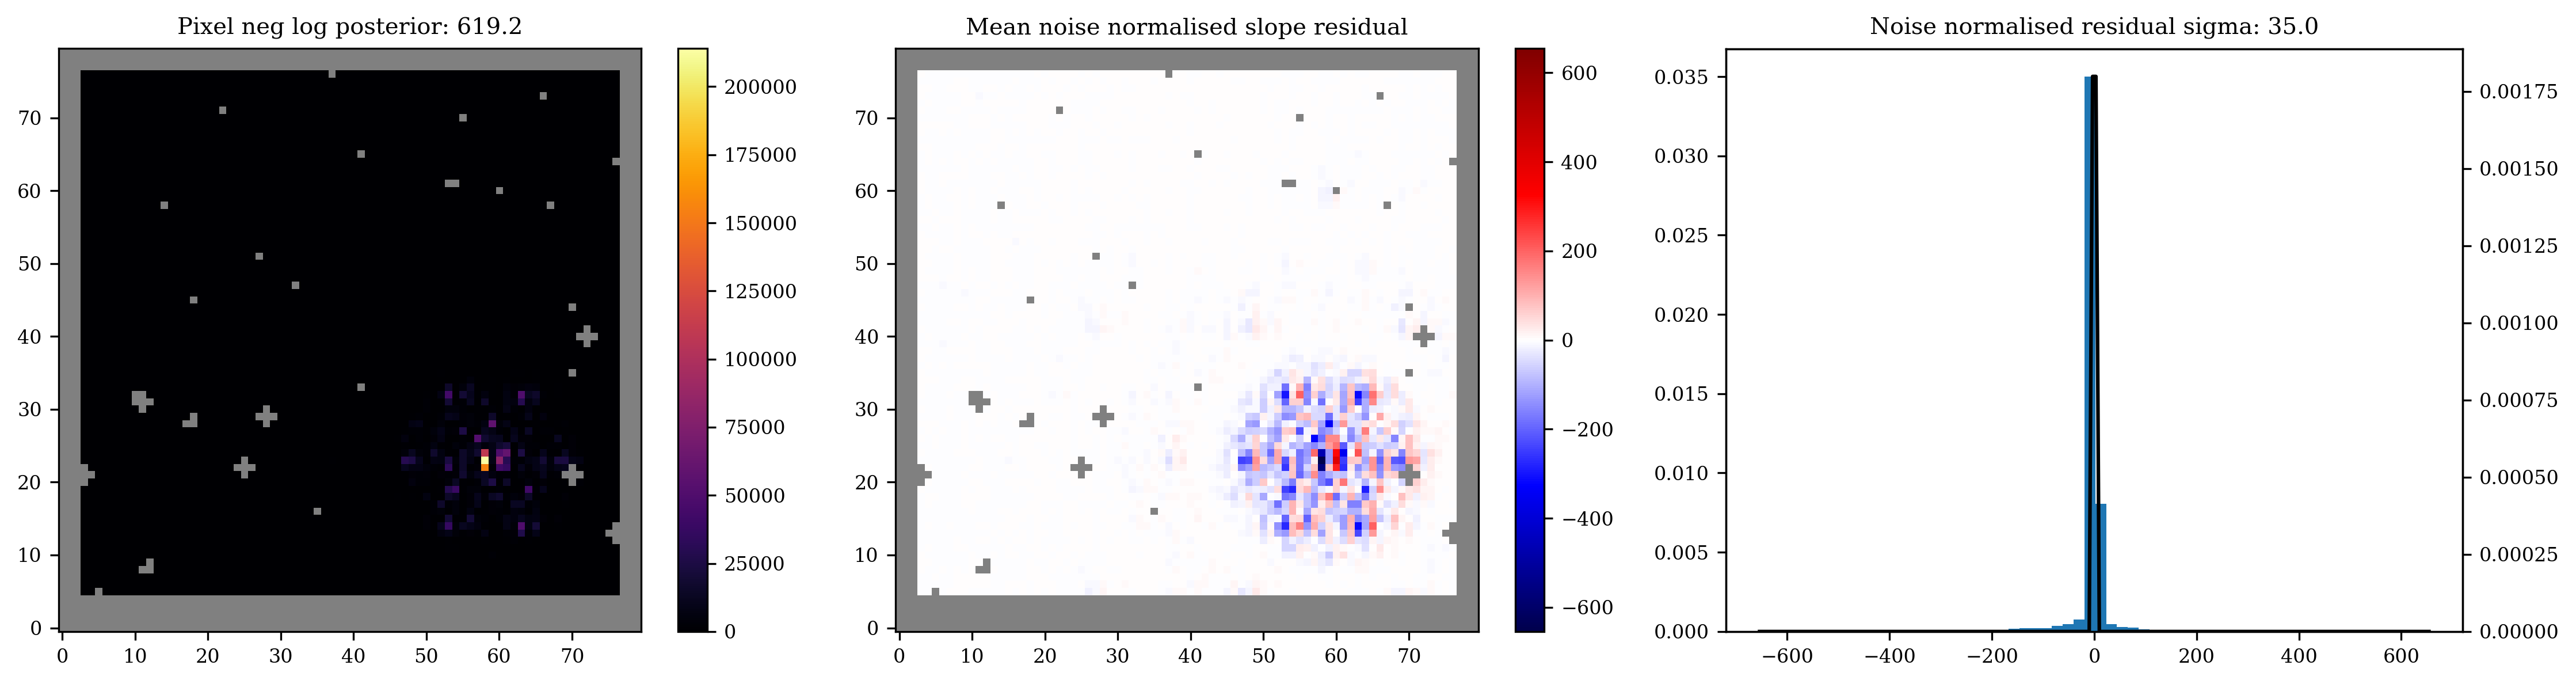

01349_F480M
Star WR137
Filter F480M
Parang 192.00 deg
Dither 1
Date 2022-07-13T11:42:10.194



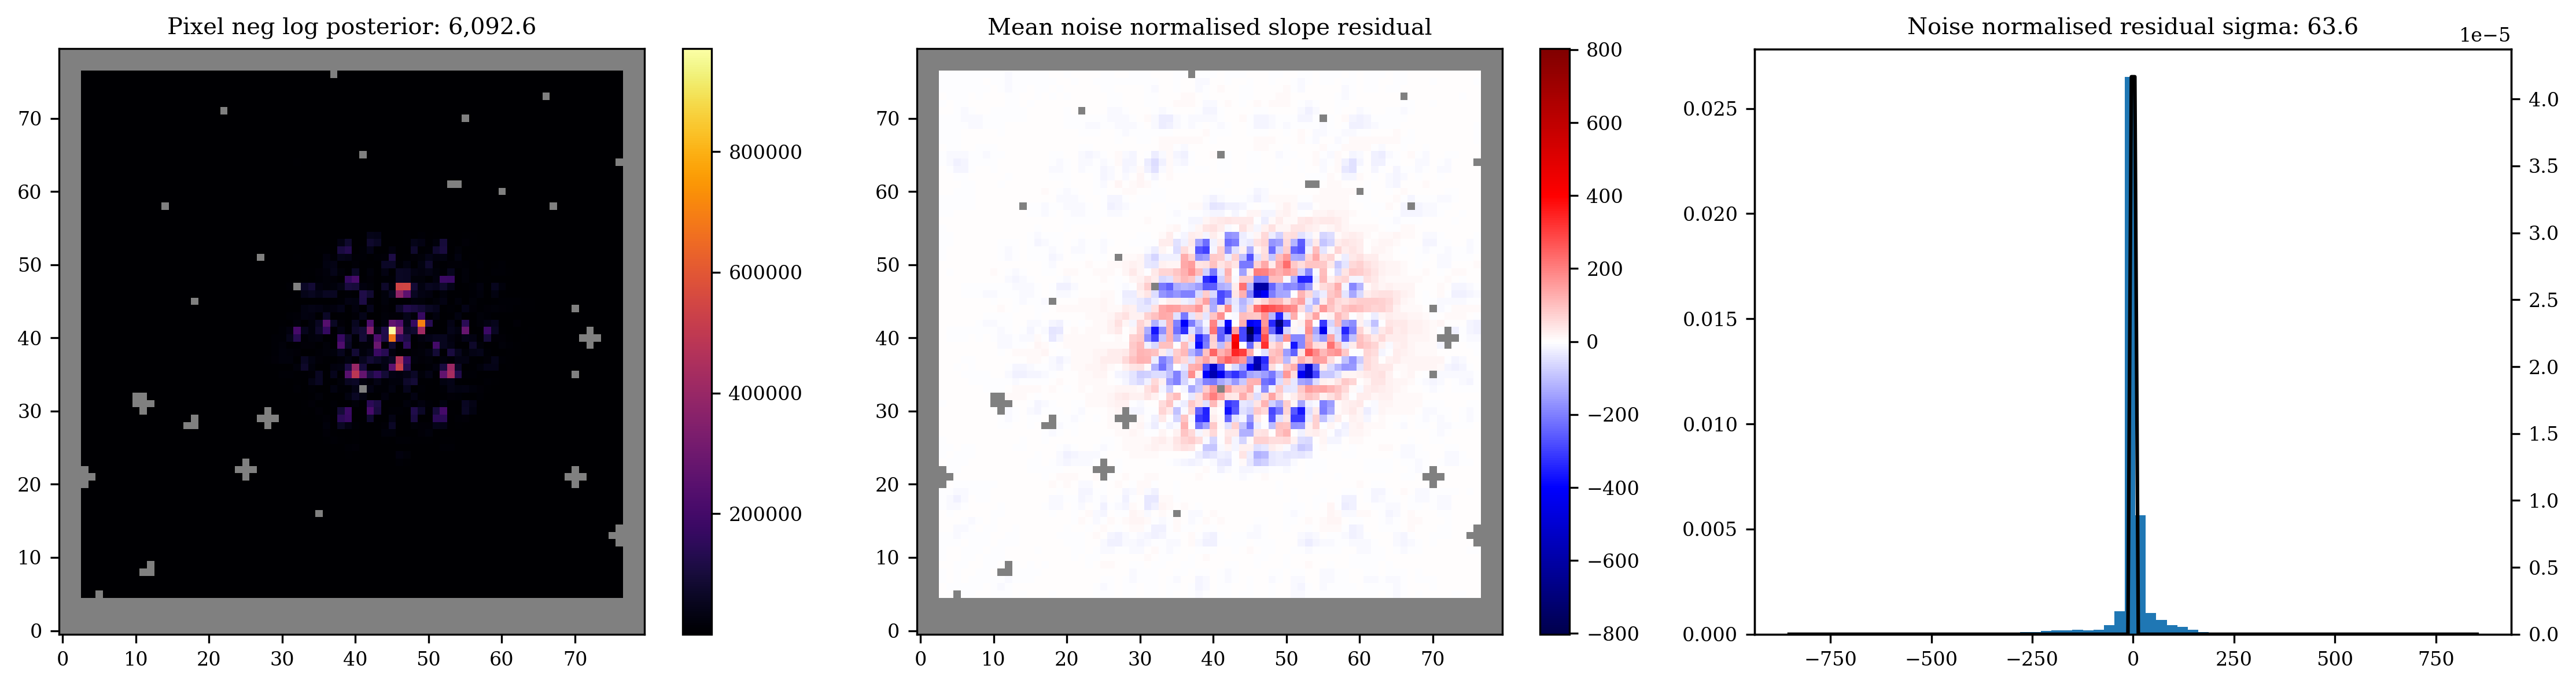

01349_F480M
Star WR137
Filter F480M
Parang 192.01 deg
Dither 2
Date 2022-07-13T11:46:01.618



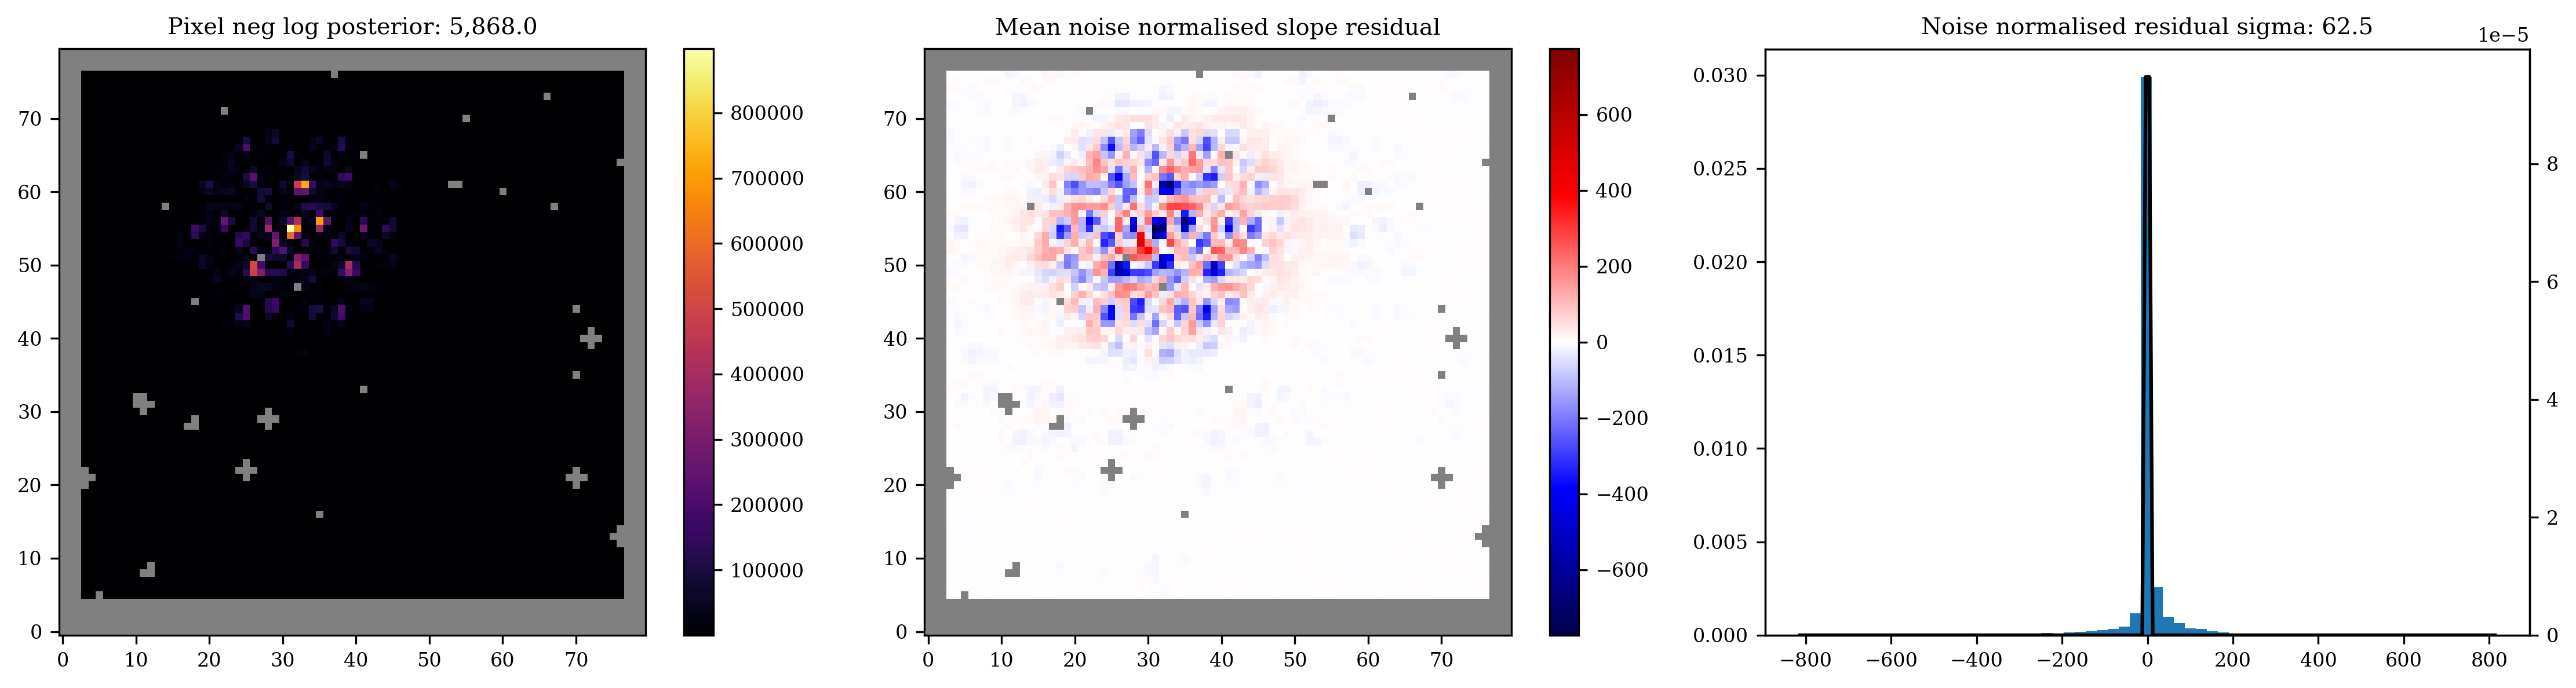

01349_F480M
Star WR137
Filter F480M
Parang 192.01 deg
Dither 3
Date 2022-07-13T11:49:54.065



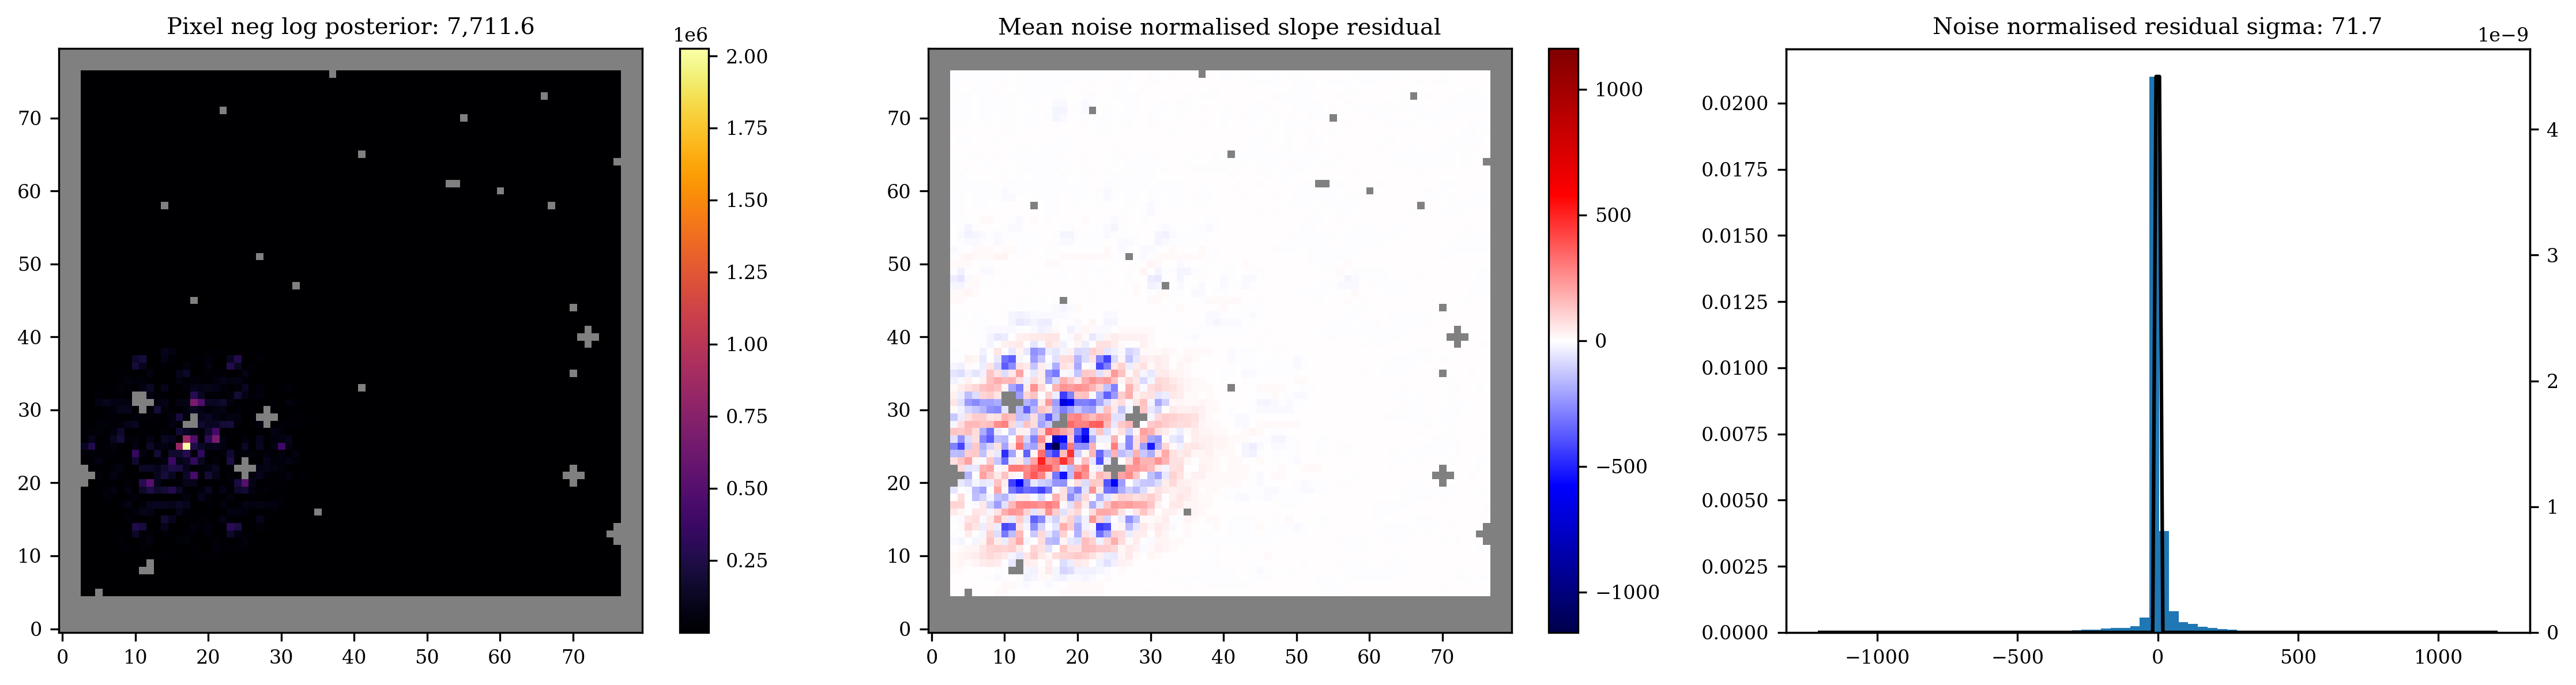

01349_F480M
Star WR137
Filter F480M
Parang 192.00 deg
Dither 4
Date 2022-07-13T11:53:45.553



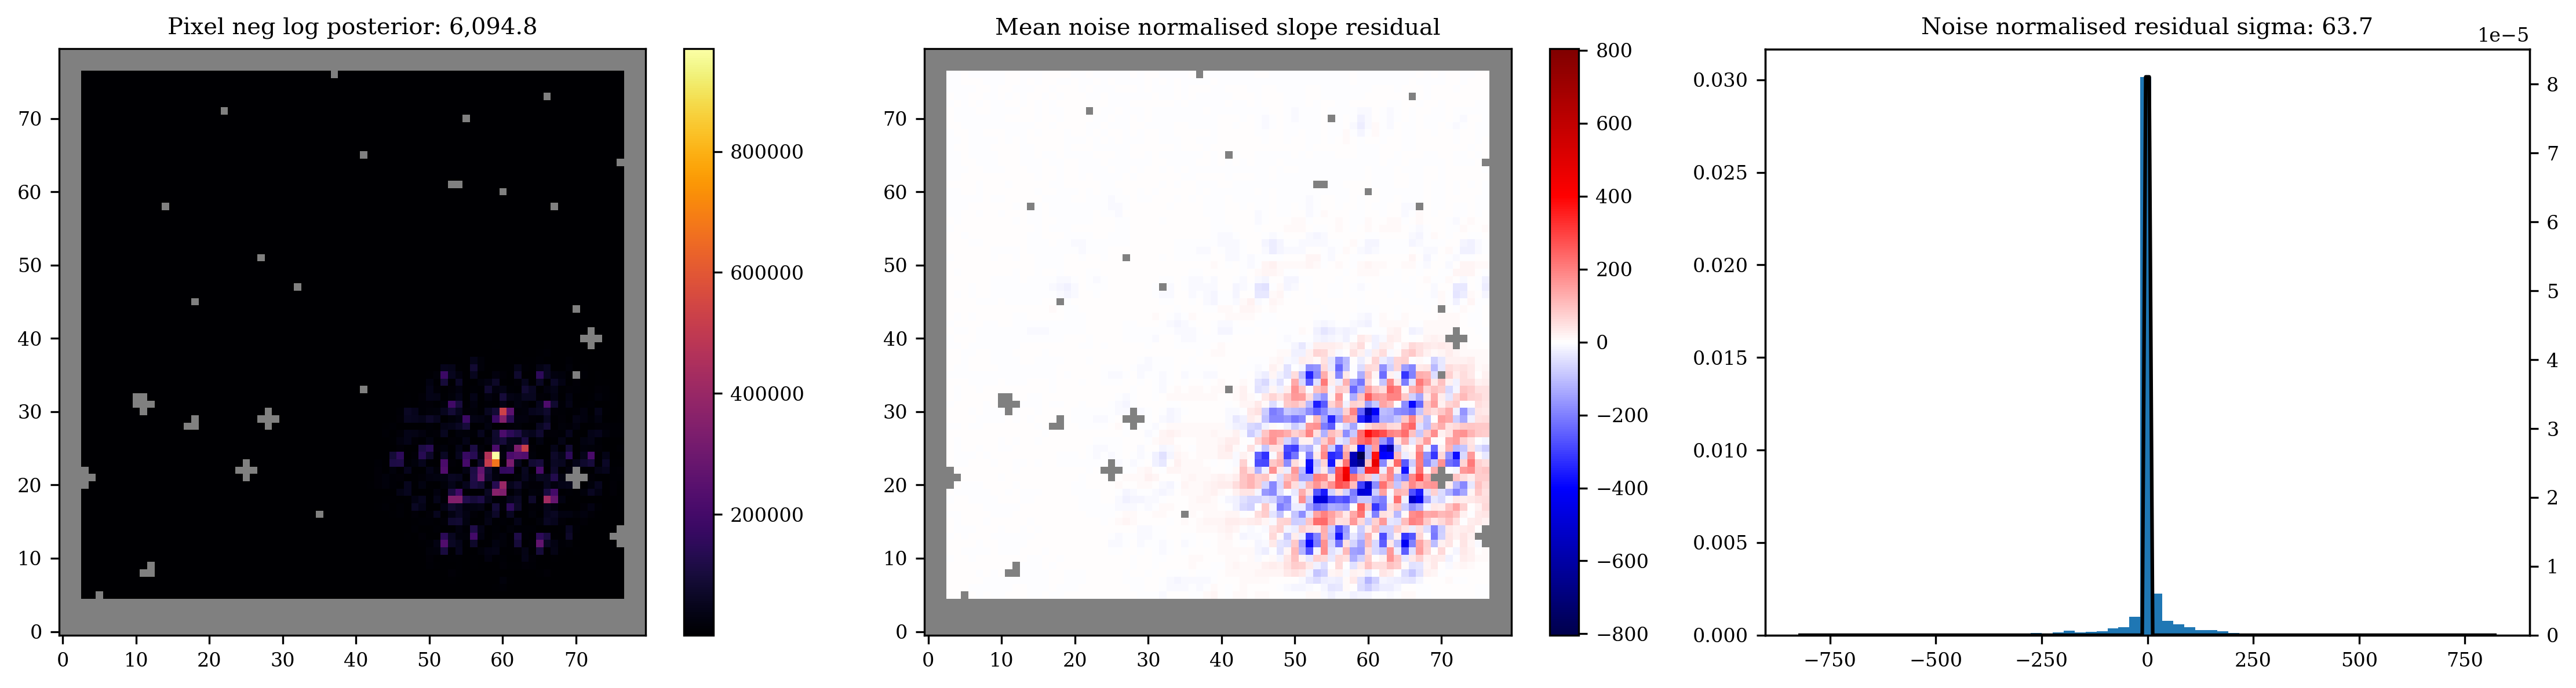

01349_F380M
Star WR137
Filter F380M
Parang 192.00 deg
Dither 1
Date 2022-07-13T11:58:59.820



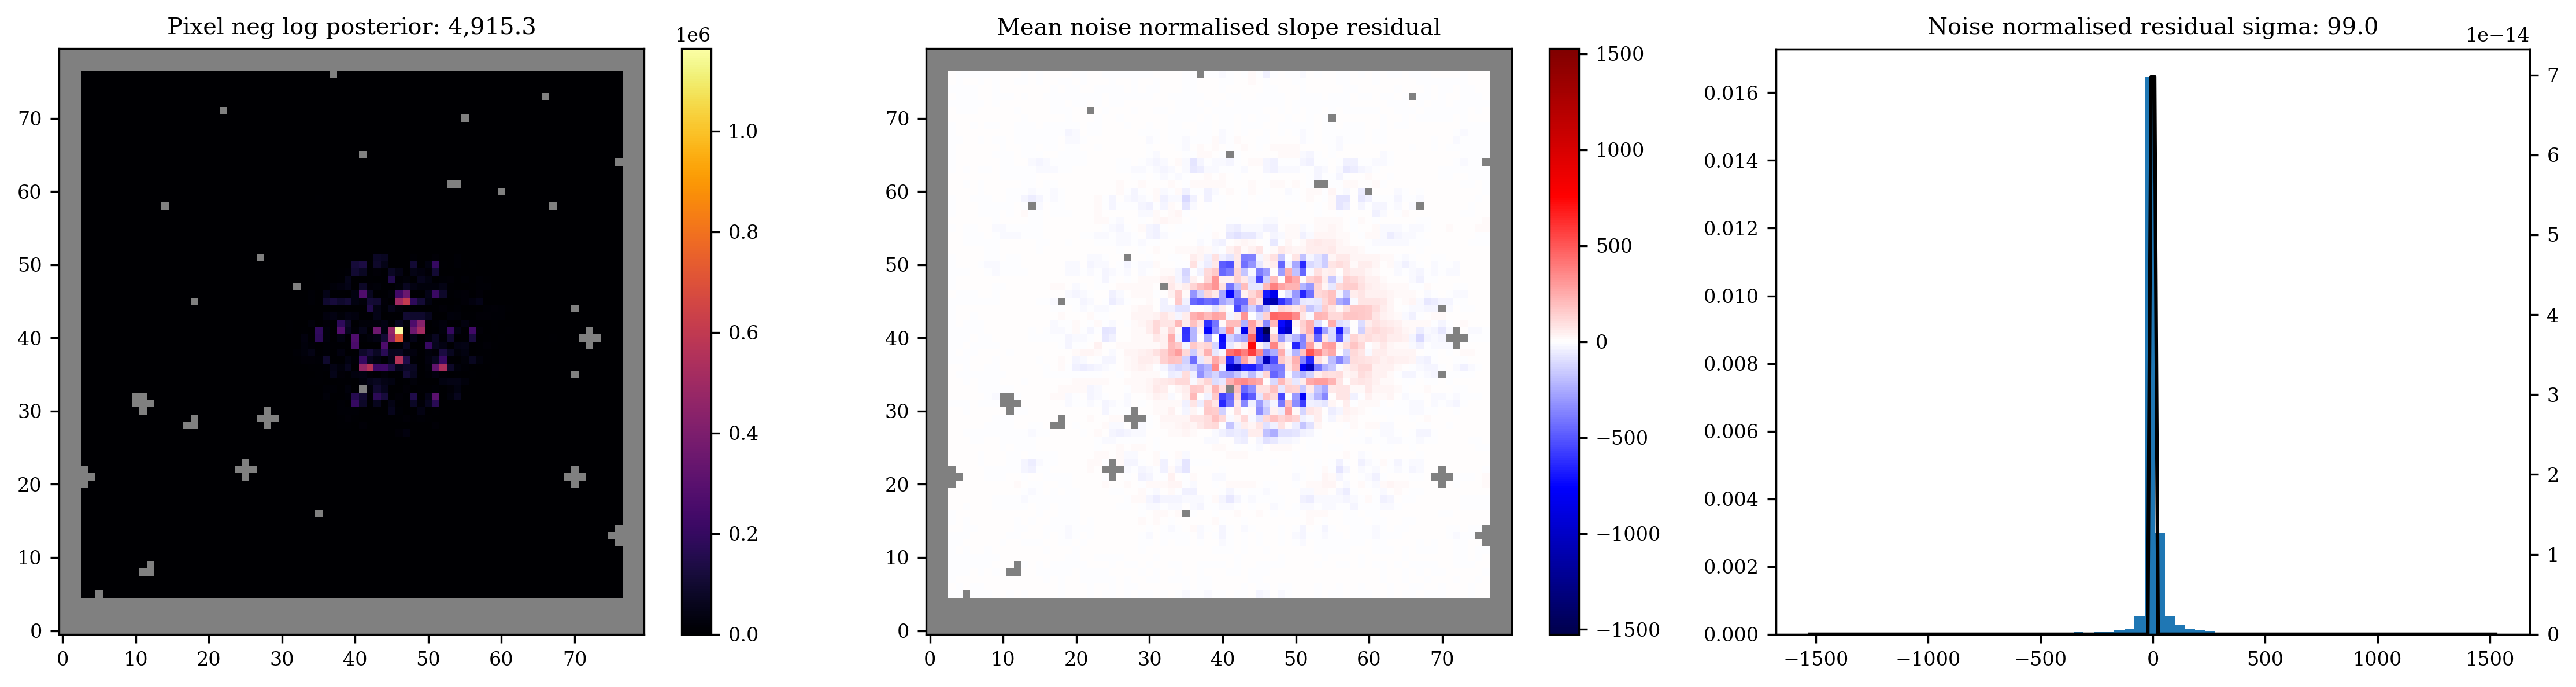

01349_F380M
Star WR137
Filter F380M
Parang 192.01 deg
Dither 2
Date 2022-07-13T12:03:02.507



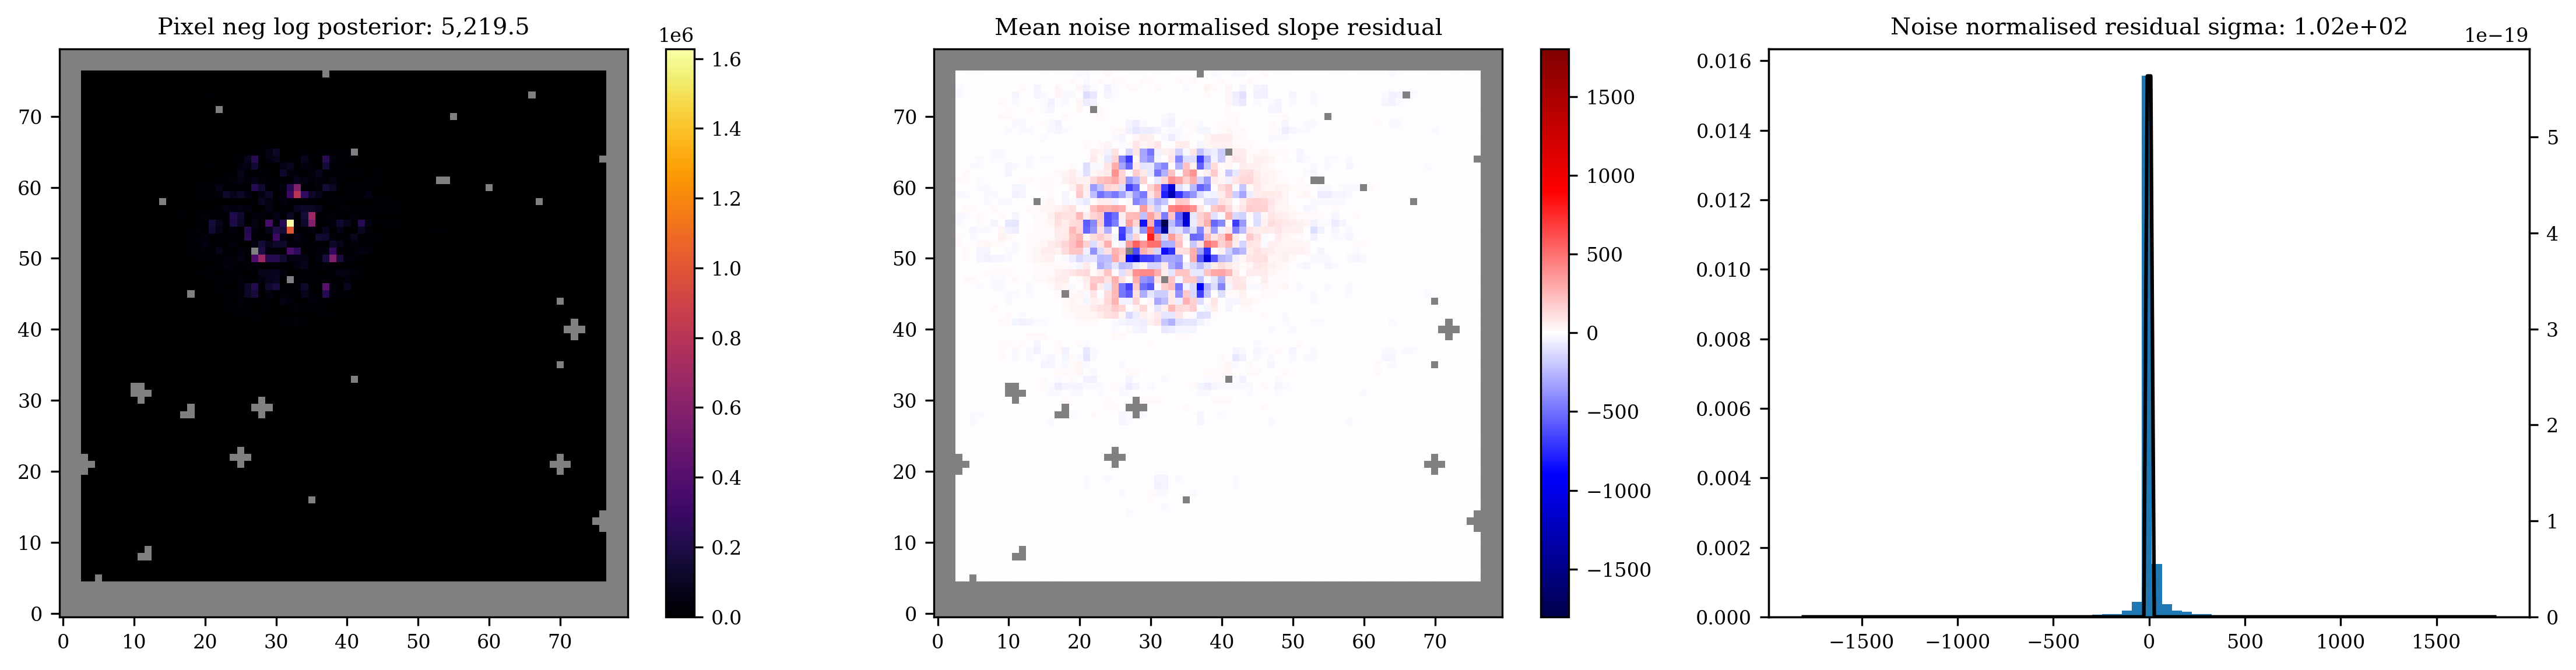

01349_F380M
Star WR137
Filter F380M
Parang 192.00 deg
Dither 4
Date 2022-07-13T12:11:07.947



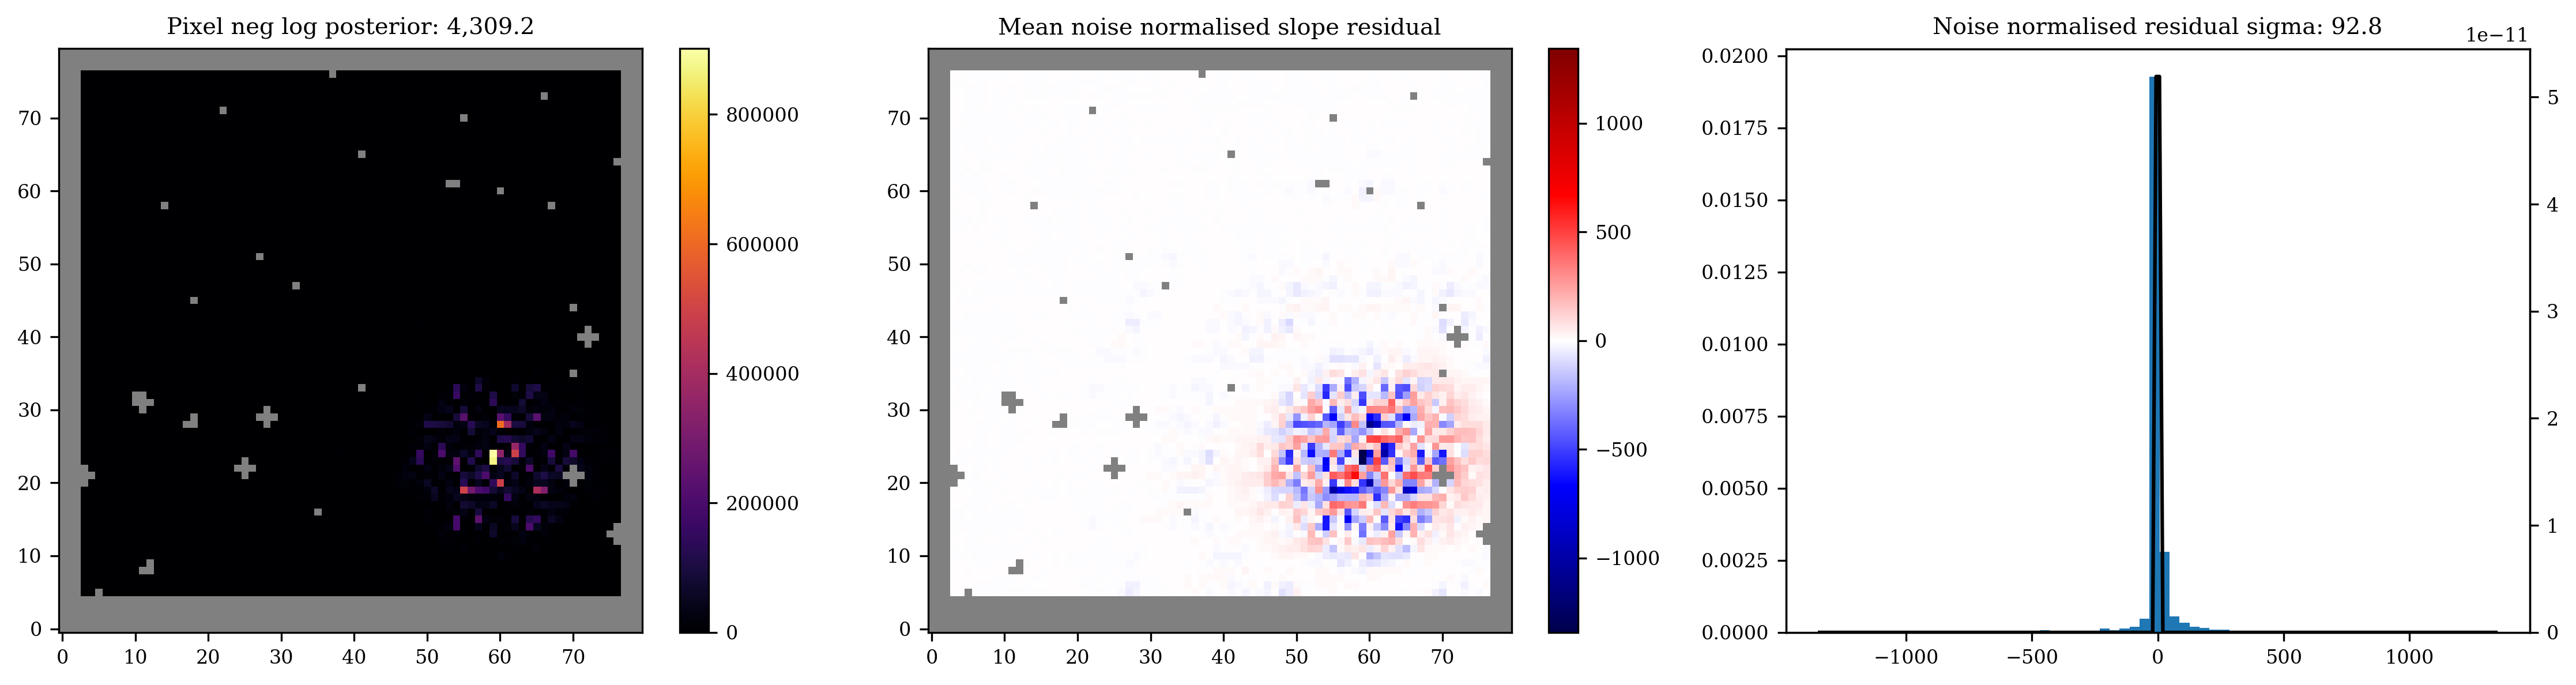

01349_F480M
Star WR137
Filter F480M
Parang 189.83 deg
Dither 1
Date 2022-07-15T12:38:42.741



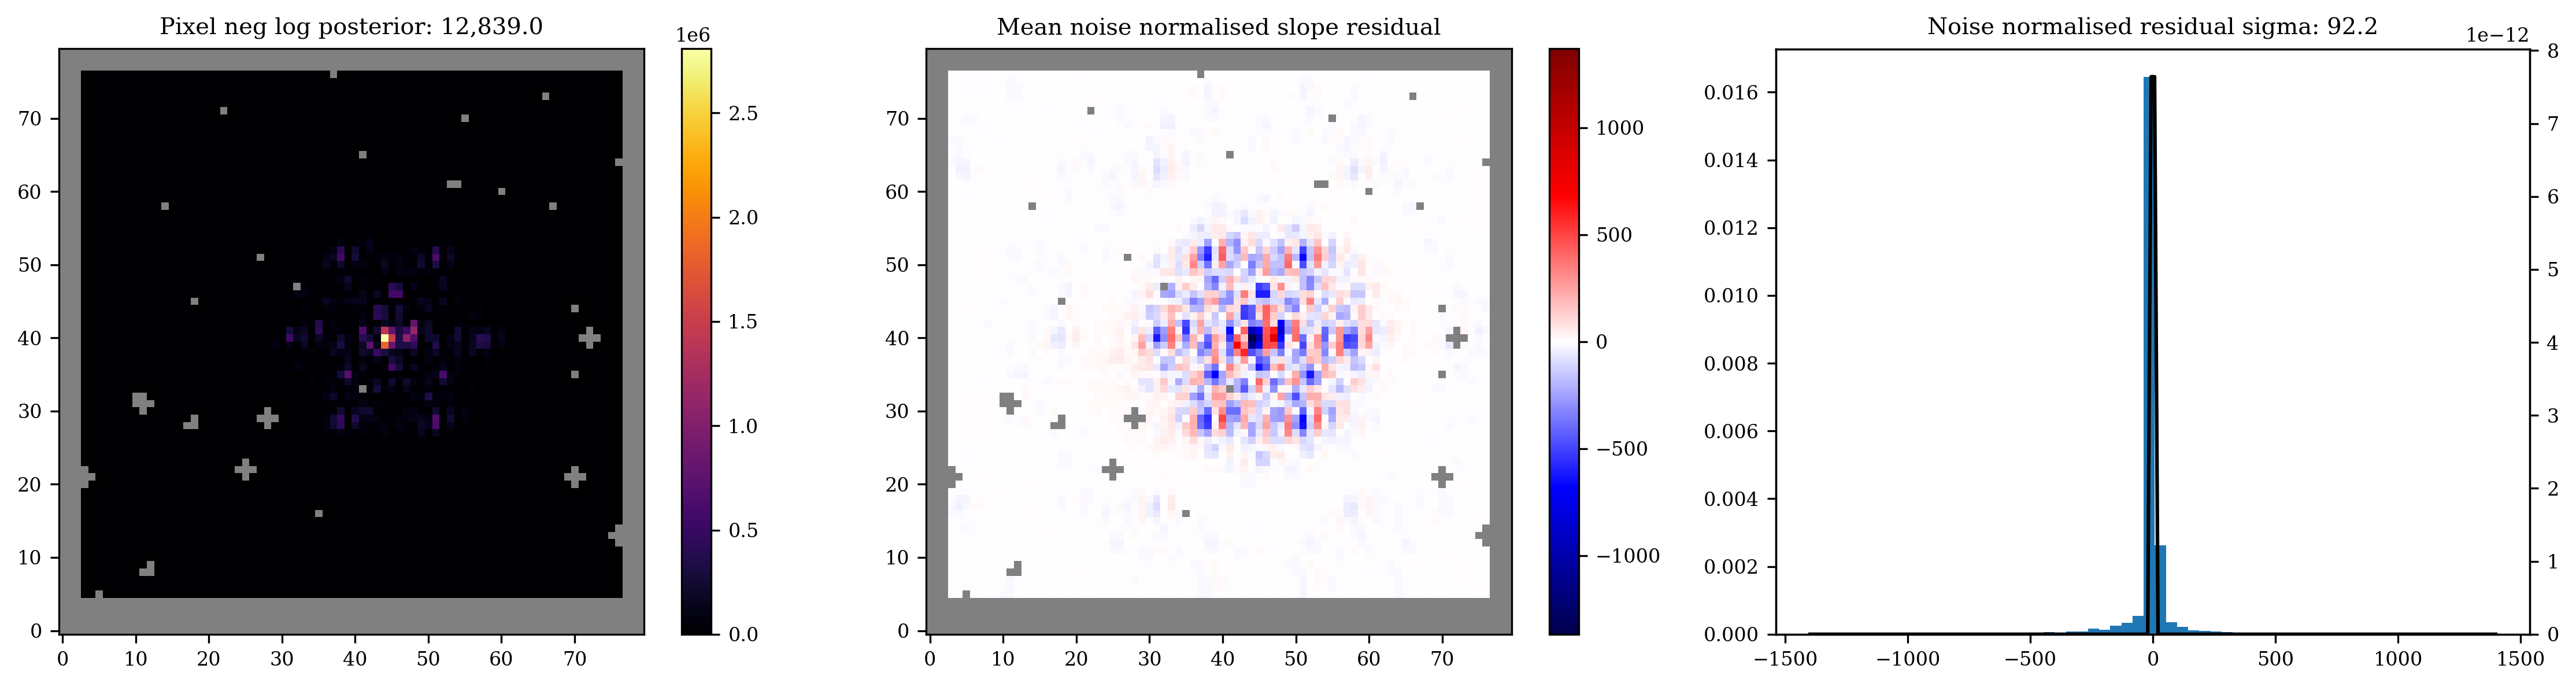

01349_F380M
Star WR137
Filter F380M
Parang 189.83 deg
Dither 1
Date 2022-07-15T12:51:09.154



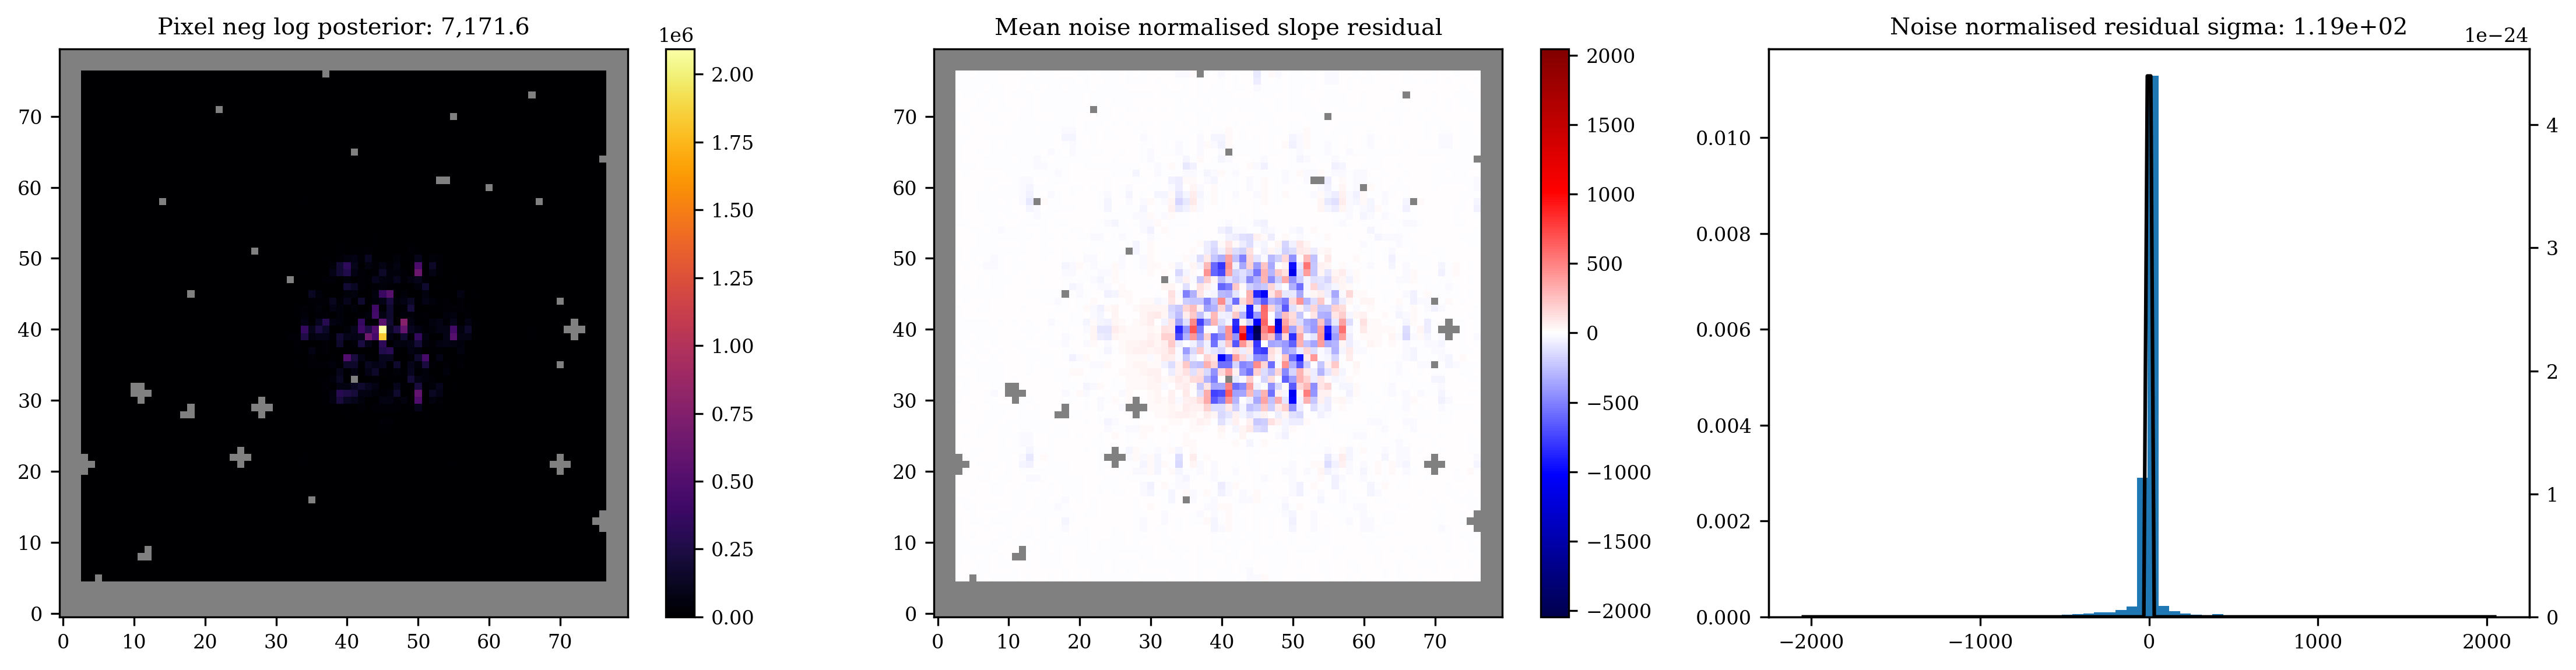

01349_F480M
Star WR137
Filter F480M
Parang 162.71 deg
Dither 1
Date 2022-08-08T18:44:08.571



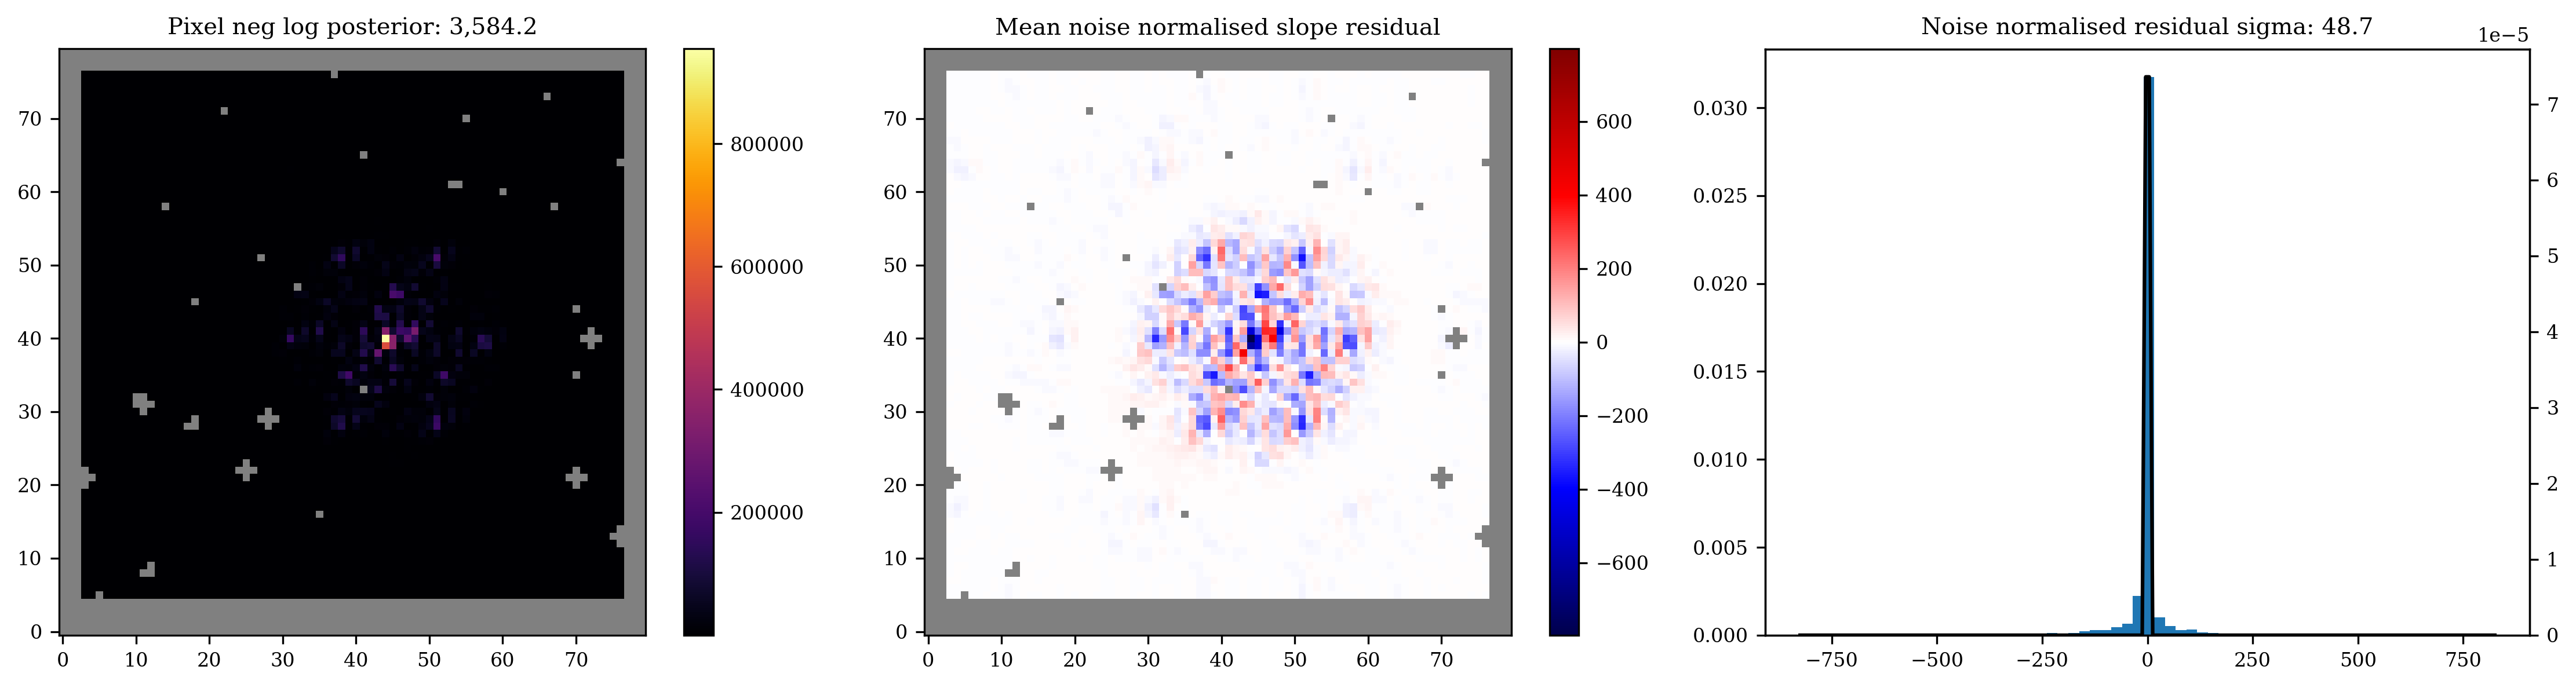

01349_F480M
Star WR137
Filter F480M
Parang 162.71 deg
Dither 2
Date 2022-08-08T18:47:59.995



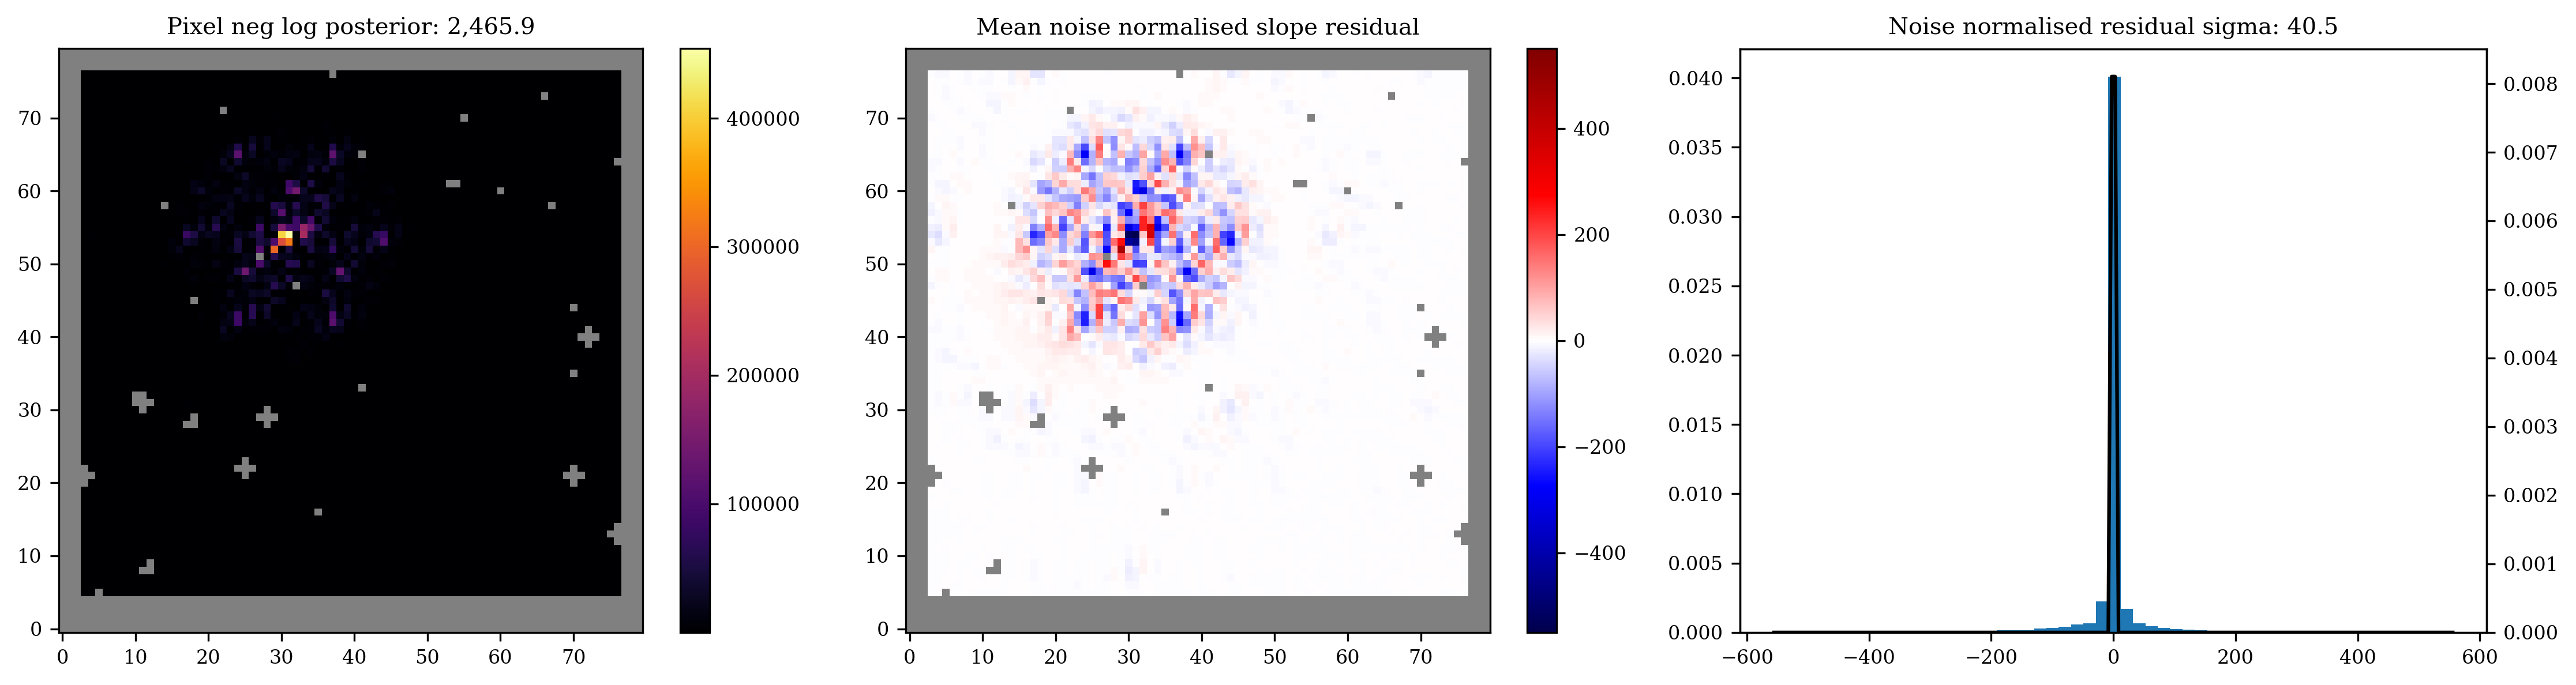

01349_F480M
Star WR137
Filter F480M
Parang 162.71 deg
Dither 3
Date 2022-08-08T18:51:51.419



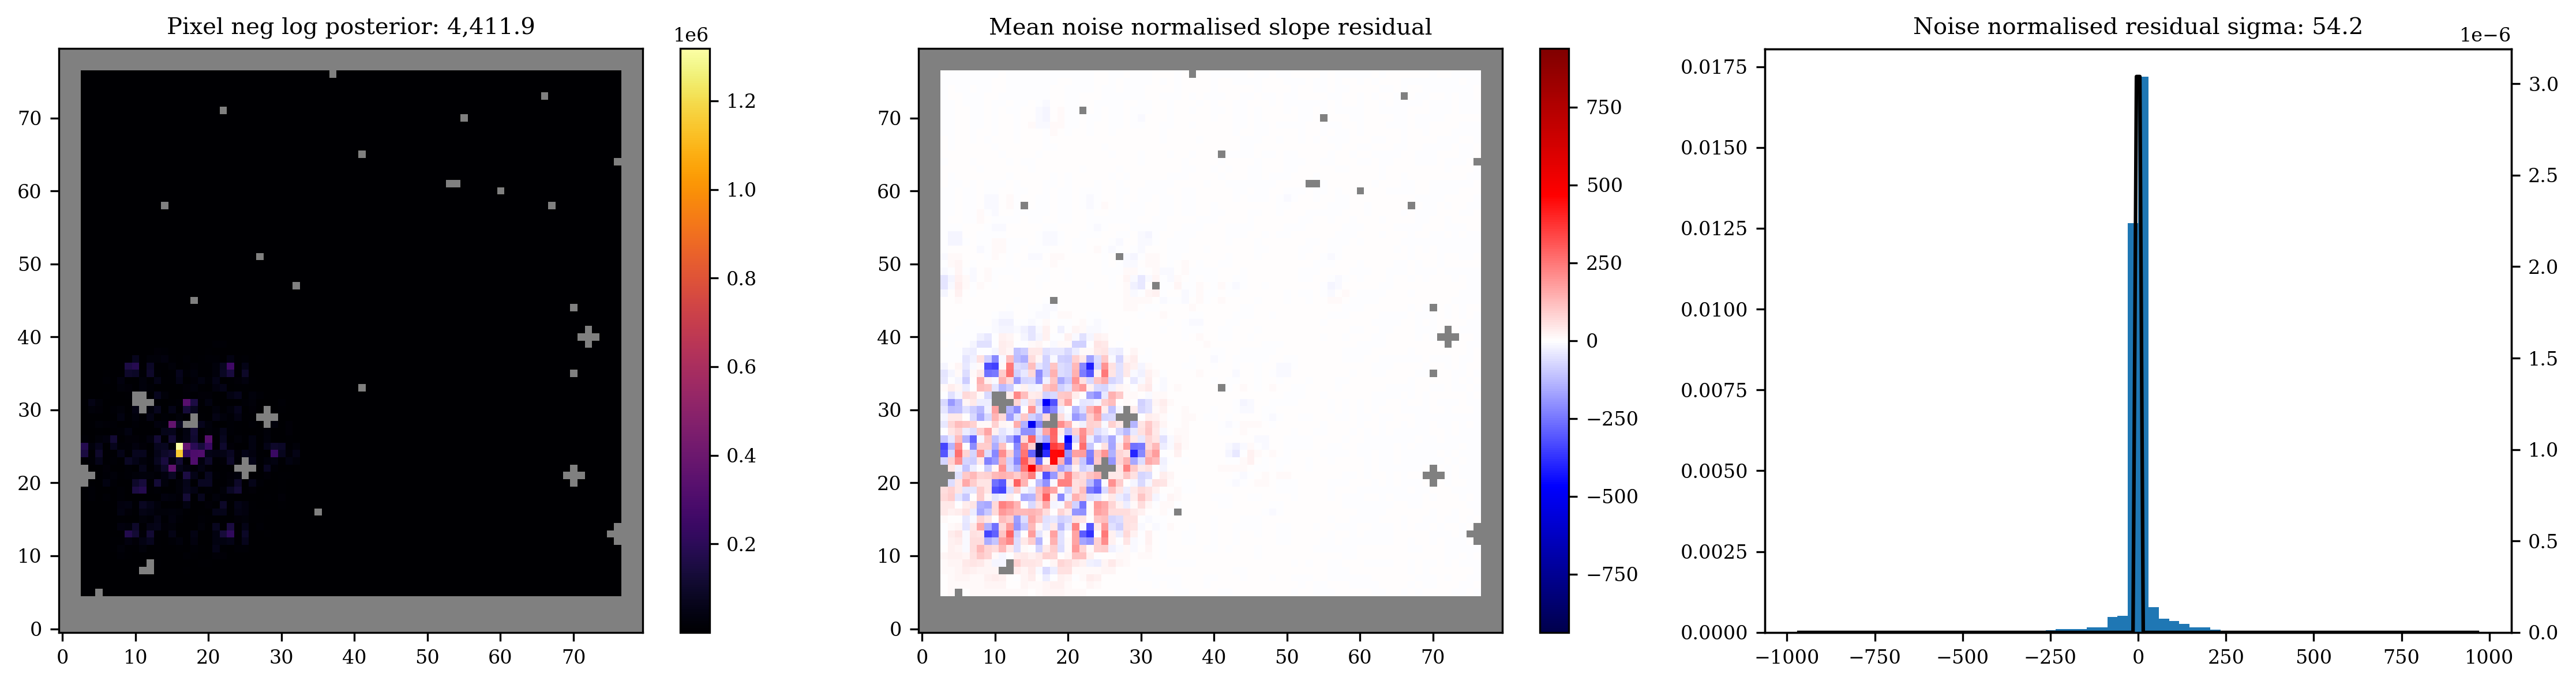

01349_F480M
Star WR137
Filter F480M
Parang 162.71 deg
Dither 4
Date 2022-08-08T18:55:42.843



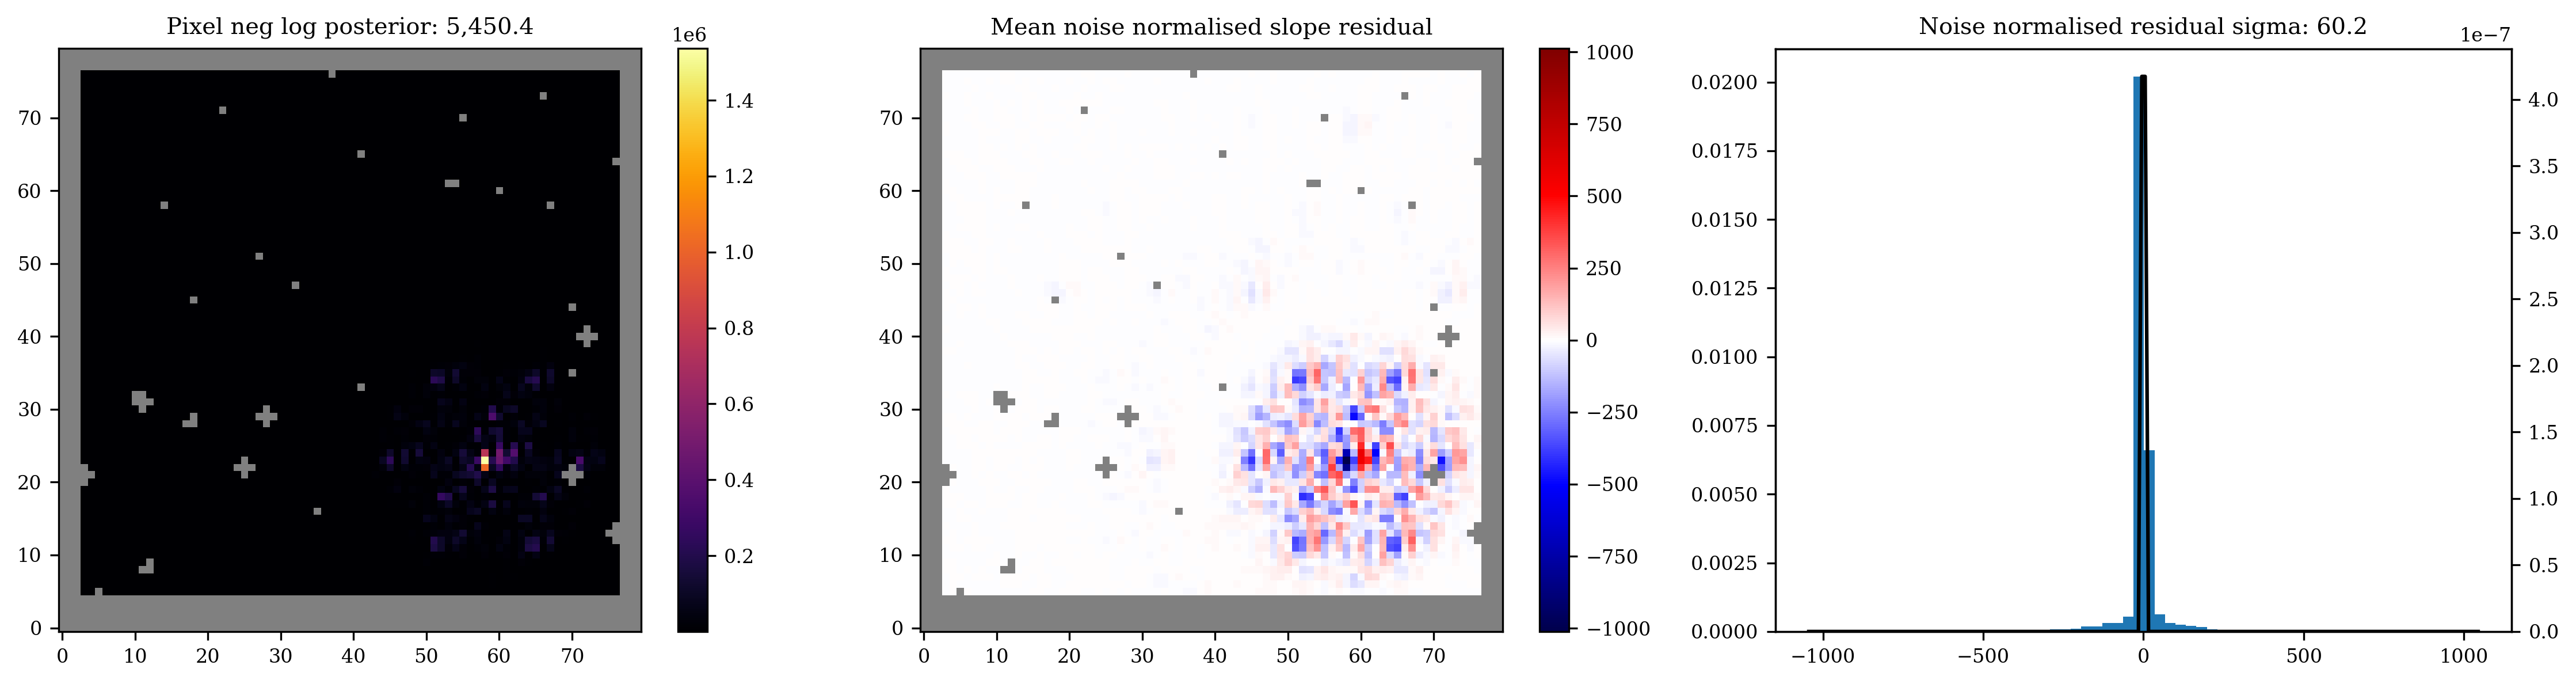

01349_F380M
Star WR137
Filter F380M
Parang 162.71 deg
Dither 1
Date 2022-08-08T19:00:58.197



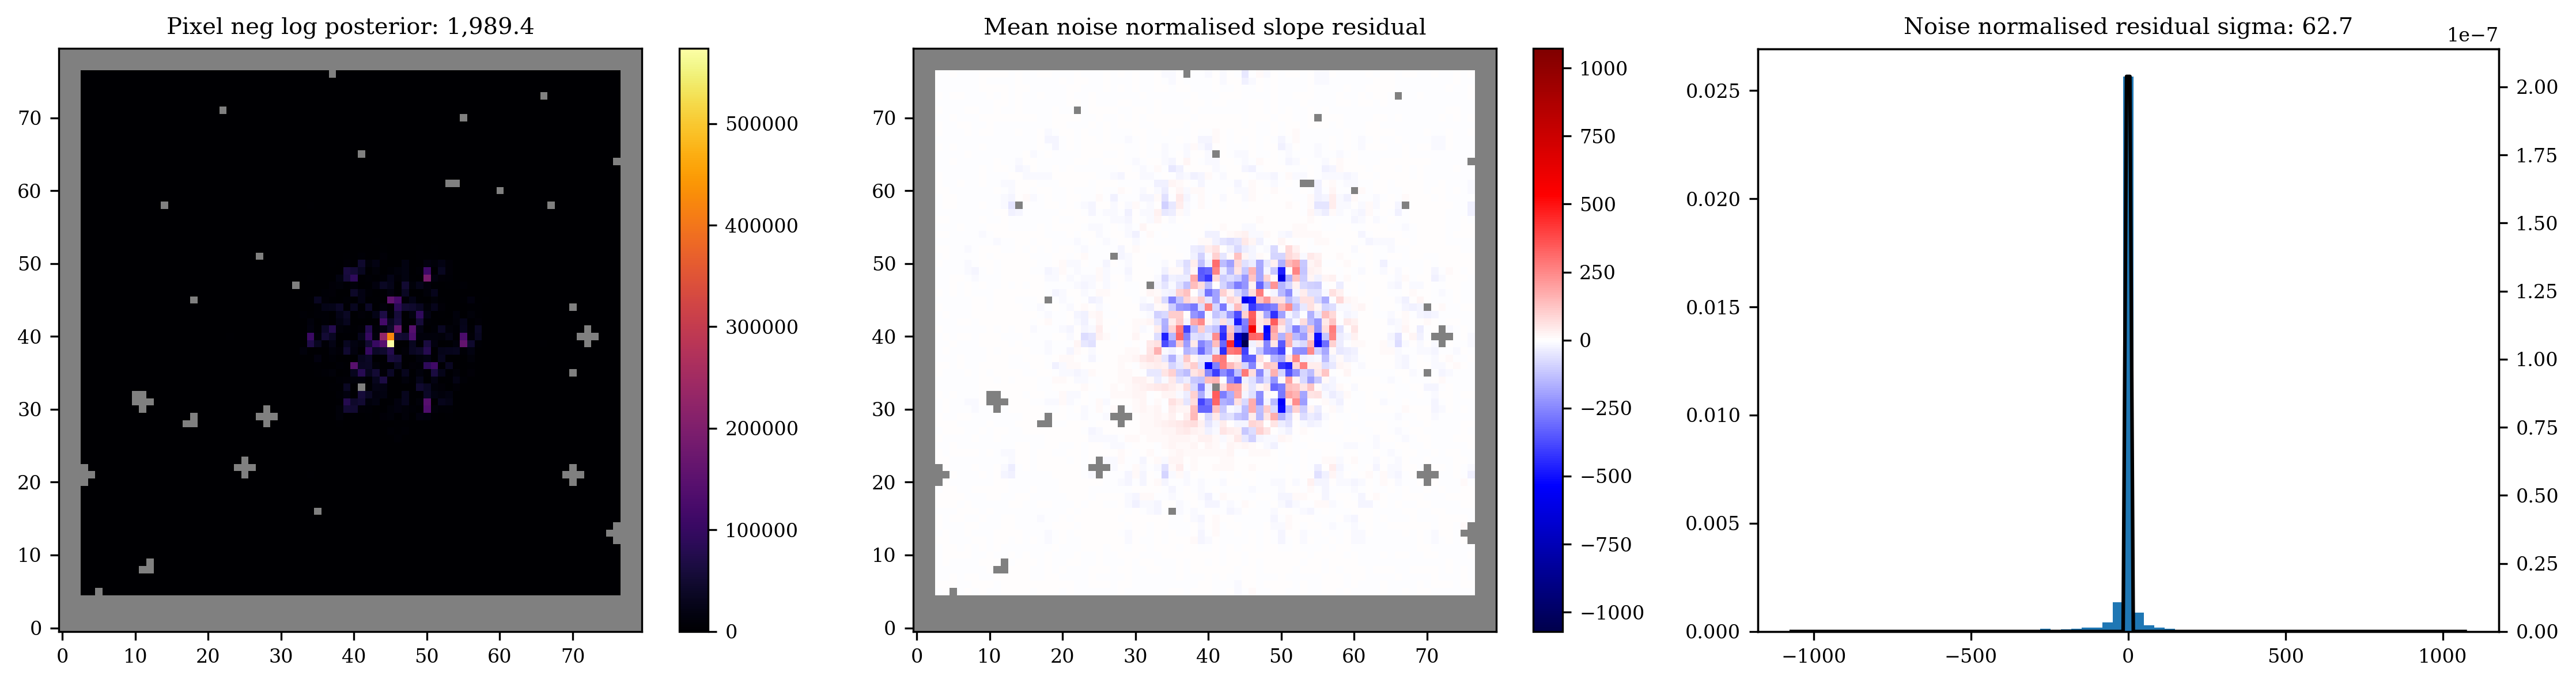

01349_F380M
Star WR137
Filter F380M
Parang 162.71 deg
Dither 2
Date 2022-08-08T19:05:00.885



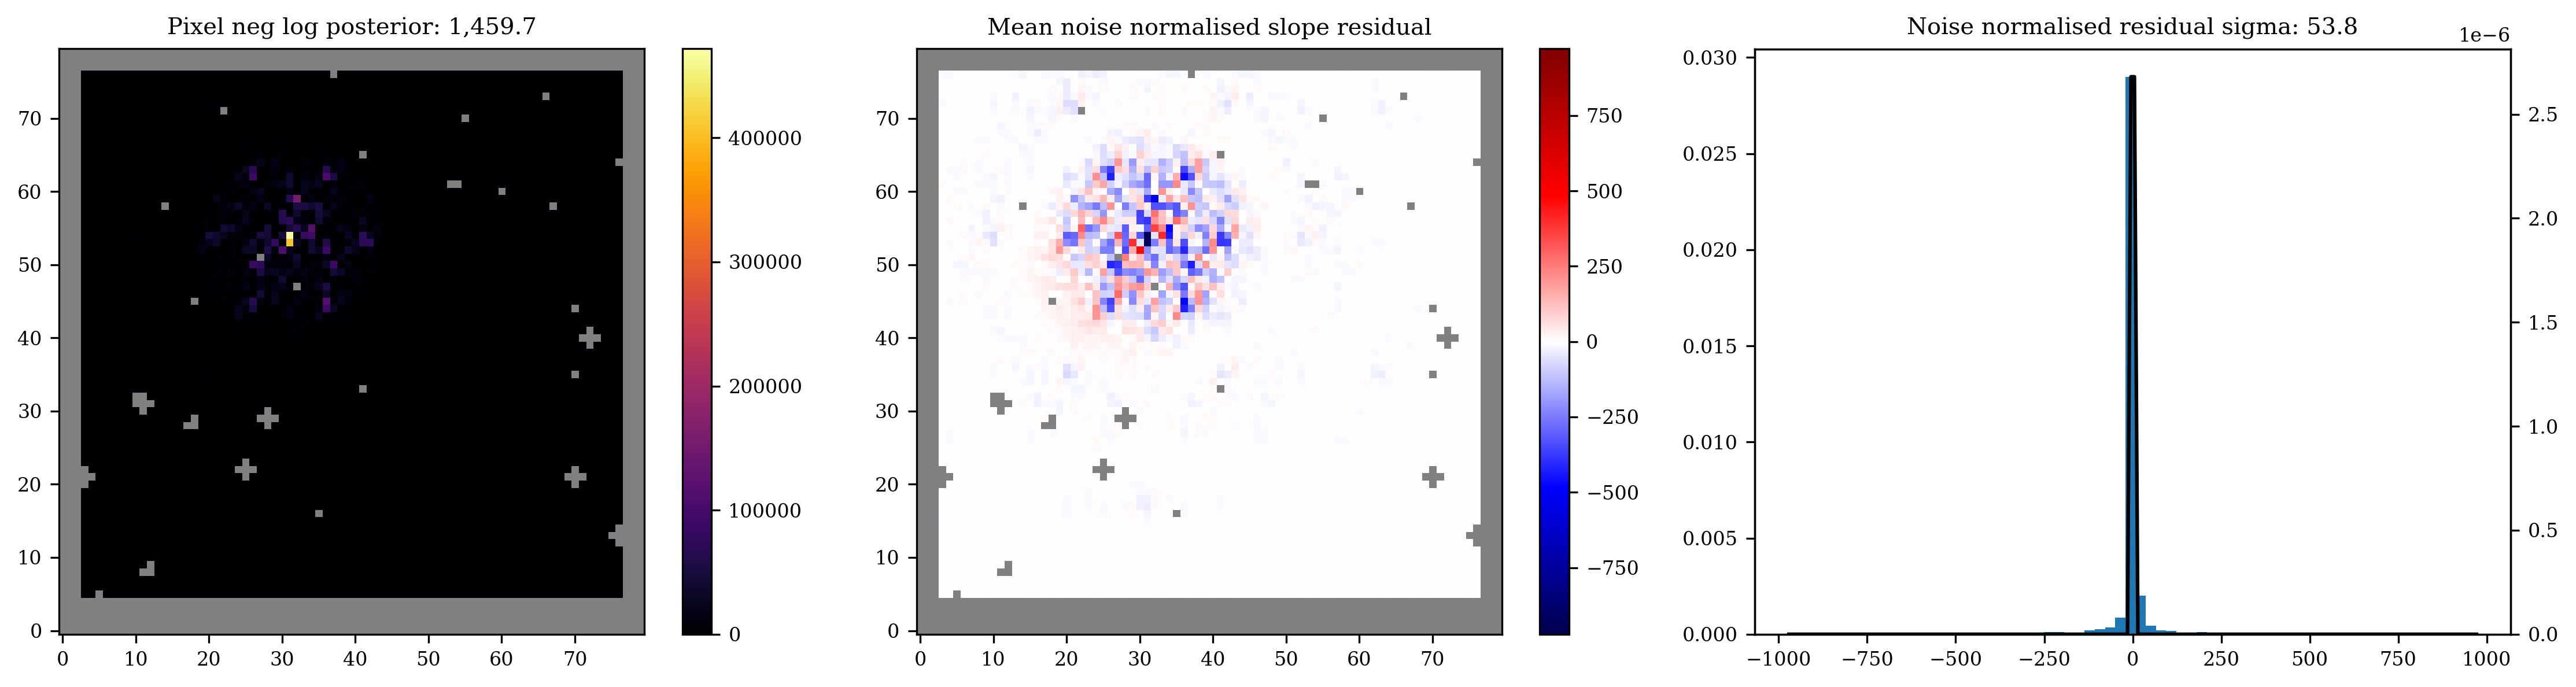

01349_F380M
Star WR137
Filter F380M
Parang 162.71 deg
Dither 3
Date 2022-08-08T19:09:03.509



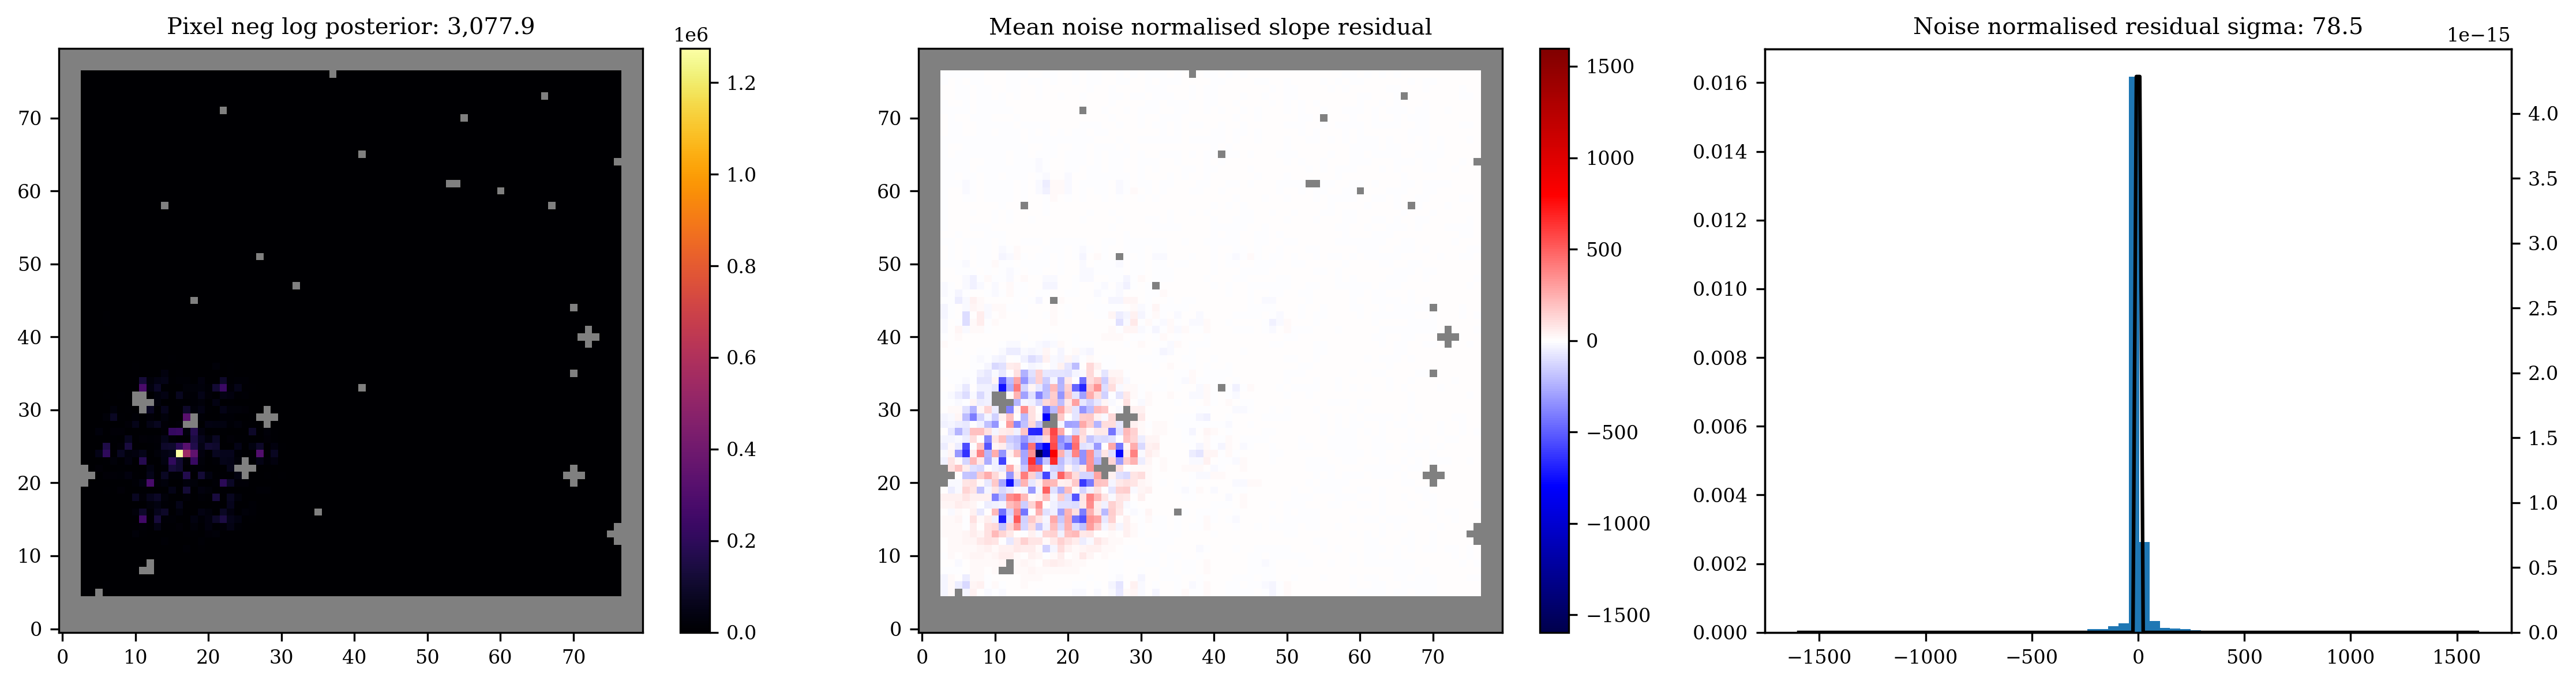

01349_F380M
Star WR137
Filter F380M
Parang 162.71 deg
Dither 4
Date 2022-08-08T19:13:06.261



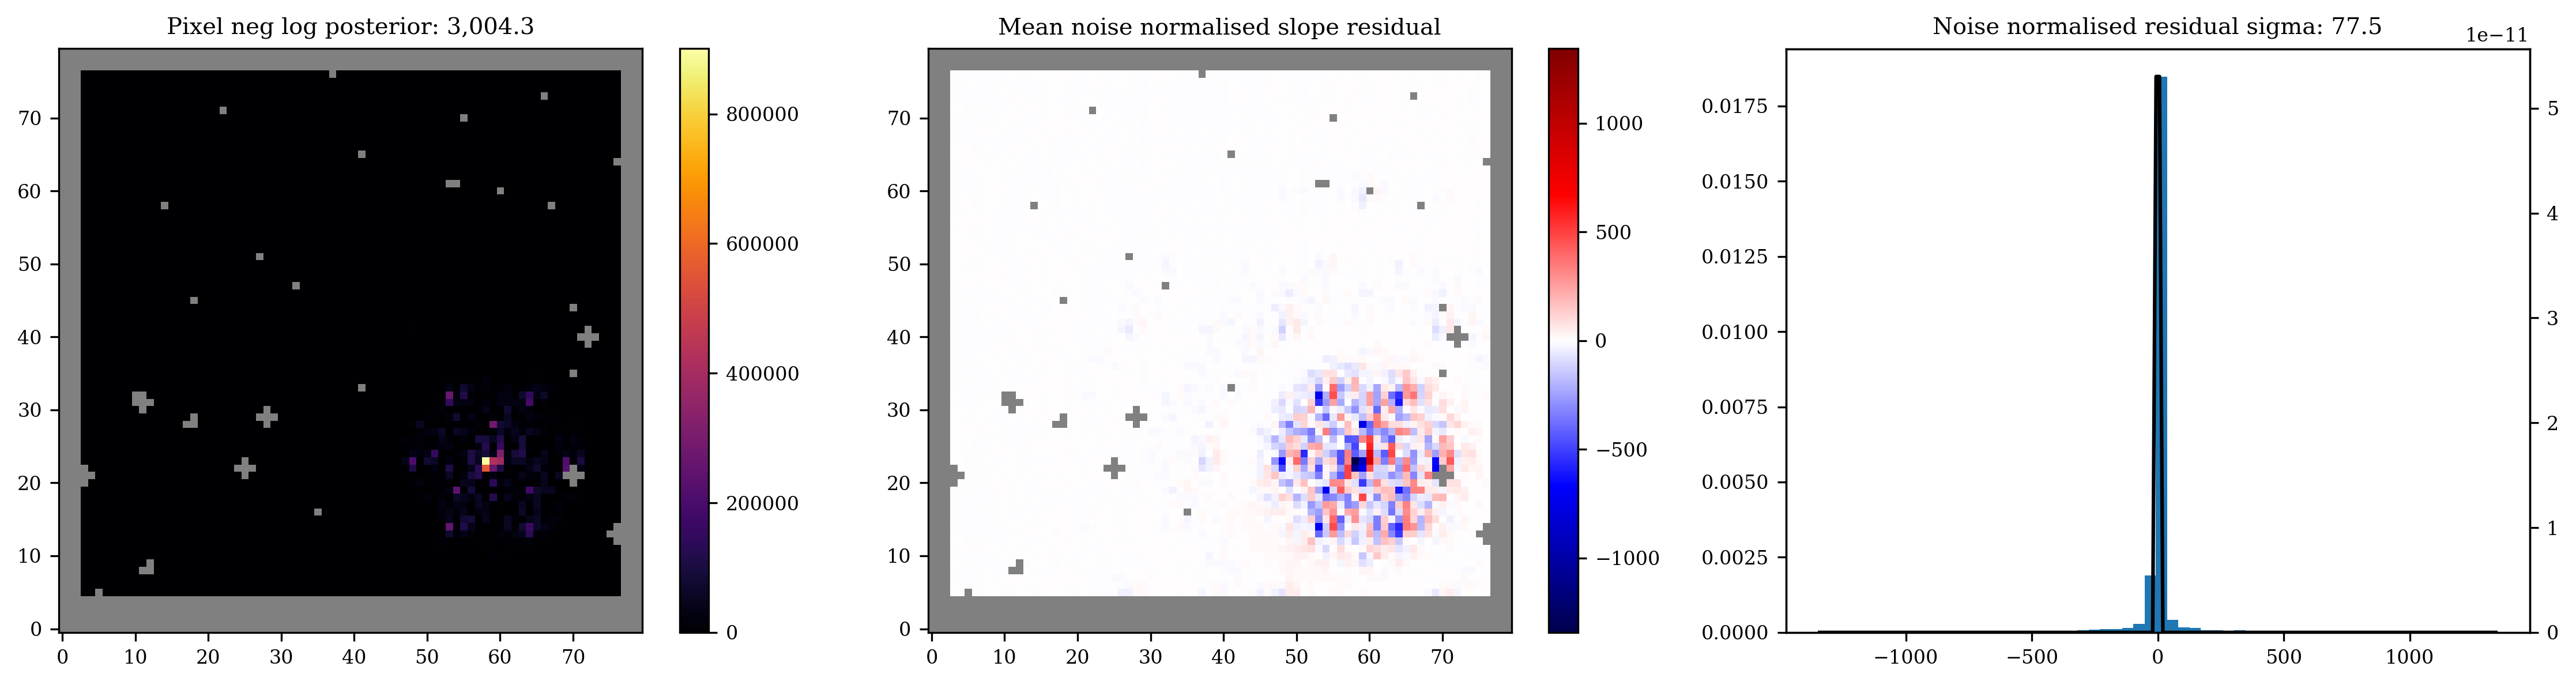

In [ ]:
for exp in exposures:
    print(exp.get_key("aberrations"))
    exp.print_summary()
    amigo.plotting.summarise_fit(model, exp, residuals=False)

In [ ]:
n_epoch = 200

config = {
    "positions": sgd(5e-1, 0),
    "fluxes": sgd(2e-1, 0),
    "aberrations": sgd(3e-2, 4),
    "spectra": sgd(2e-1, 10),
    "phases": sgd(2e0, 20),
    "amplitudes": sgd(2e0, 20),
}

trainer = amigo.fitting.Trainer(
    cache=os.path.join(amigo_cache, "fishers/"),
)

trainer = trainer.populate_fishers(
    # model.set("detector.ramp.bleed", False).set("params", params),
    model,
    exposures,
    hessians=load_dict(cache + "jac_outputs.npy")["hessian"],
    parameters=list(config.keys()),
)

print("Number of exposures: ", len(exposures))

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    # batches=batches,
    batches=amigo.fitting.batch_exposures(exposures, n_batch=15),
    # batches=amigo.fitting.batch_exposures(exposures, n_batch=len(exposures) // 2),
    # batches=exposures,
)

Number of exposures:  27


  0%|          | 0/200 [00:00<?, ?it/s]

Compiling Loss function...
Compiling Loss function...
Compiling Loss function...
Compiling Loss function...
Compiling Loss function...


2025-05-23 16:10:33.956706: W external/xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 10.13GiB (rounded to 10880477952)requested by op 
2025-05-23 16:10:33.959137: W external/xla/xla/tsl/framework/bfc_allocator.cc:512] ***_________________________________________________________________________________________________
E0523 16:10:33.959268  382938 pjrt_stream_executor_client.cc:2839] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 10880477736 bytes. [tf-allocator-allocation-error='']


XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 10880477736 bytes.

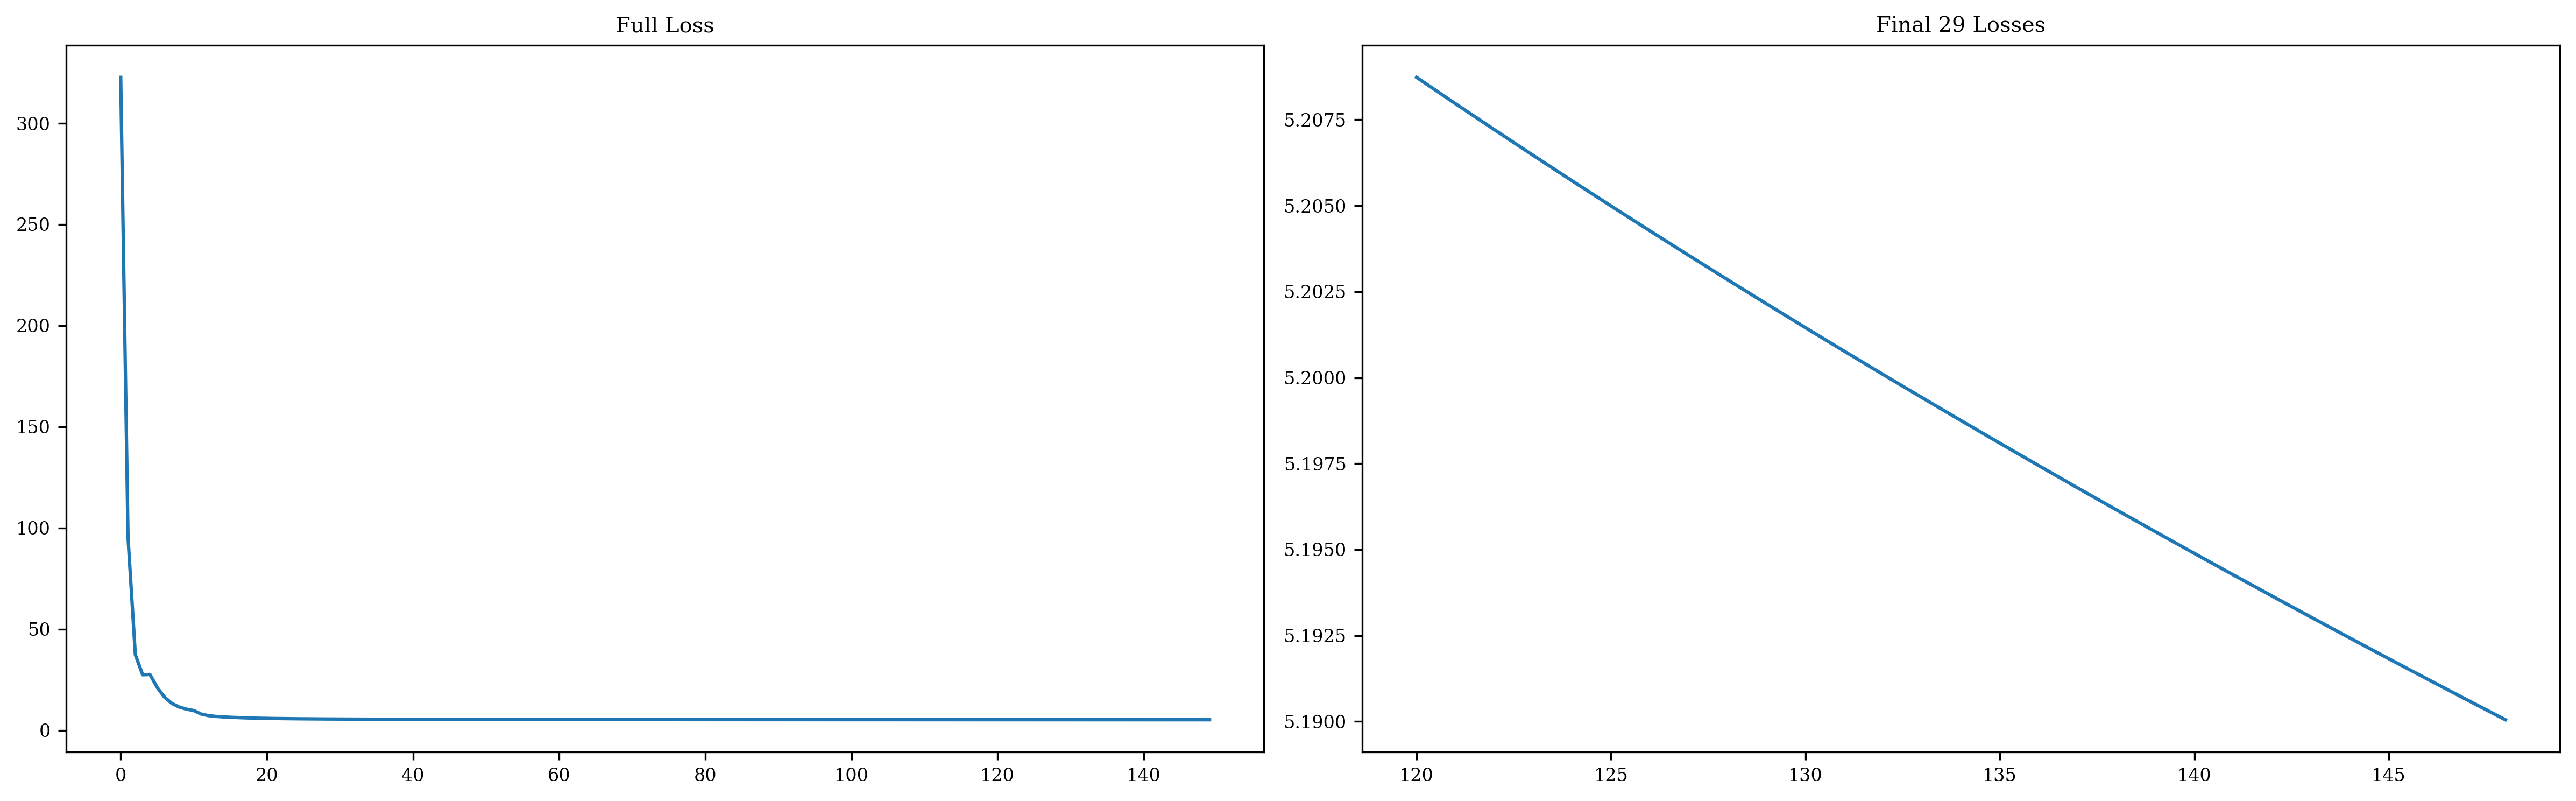

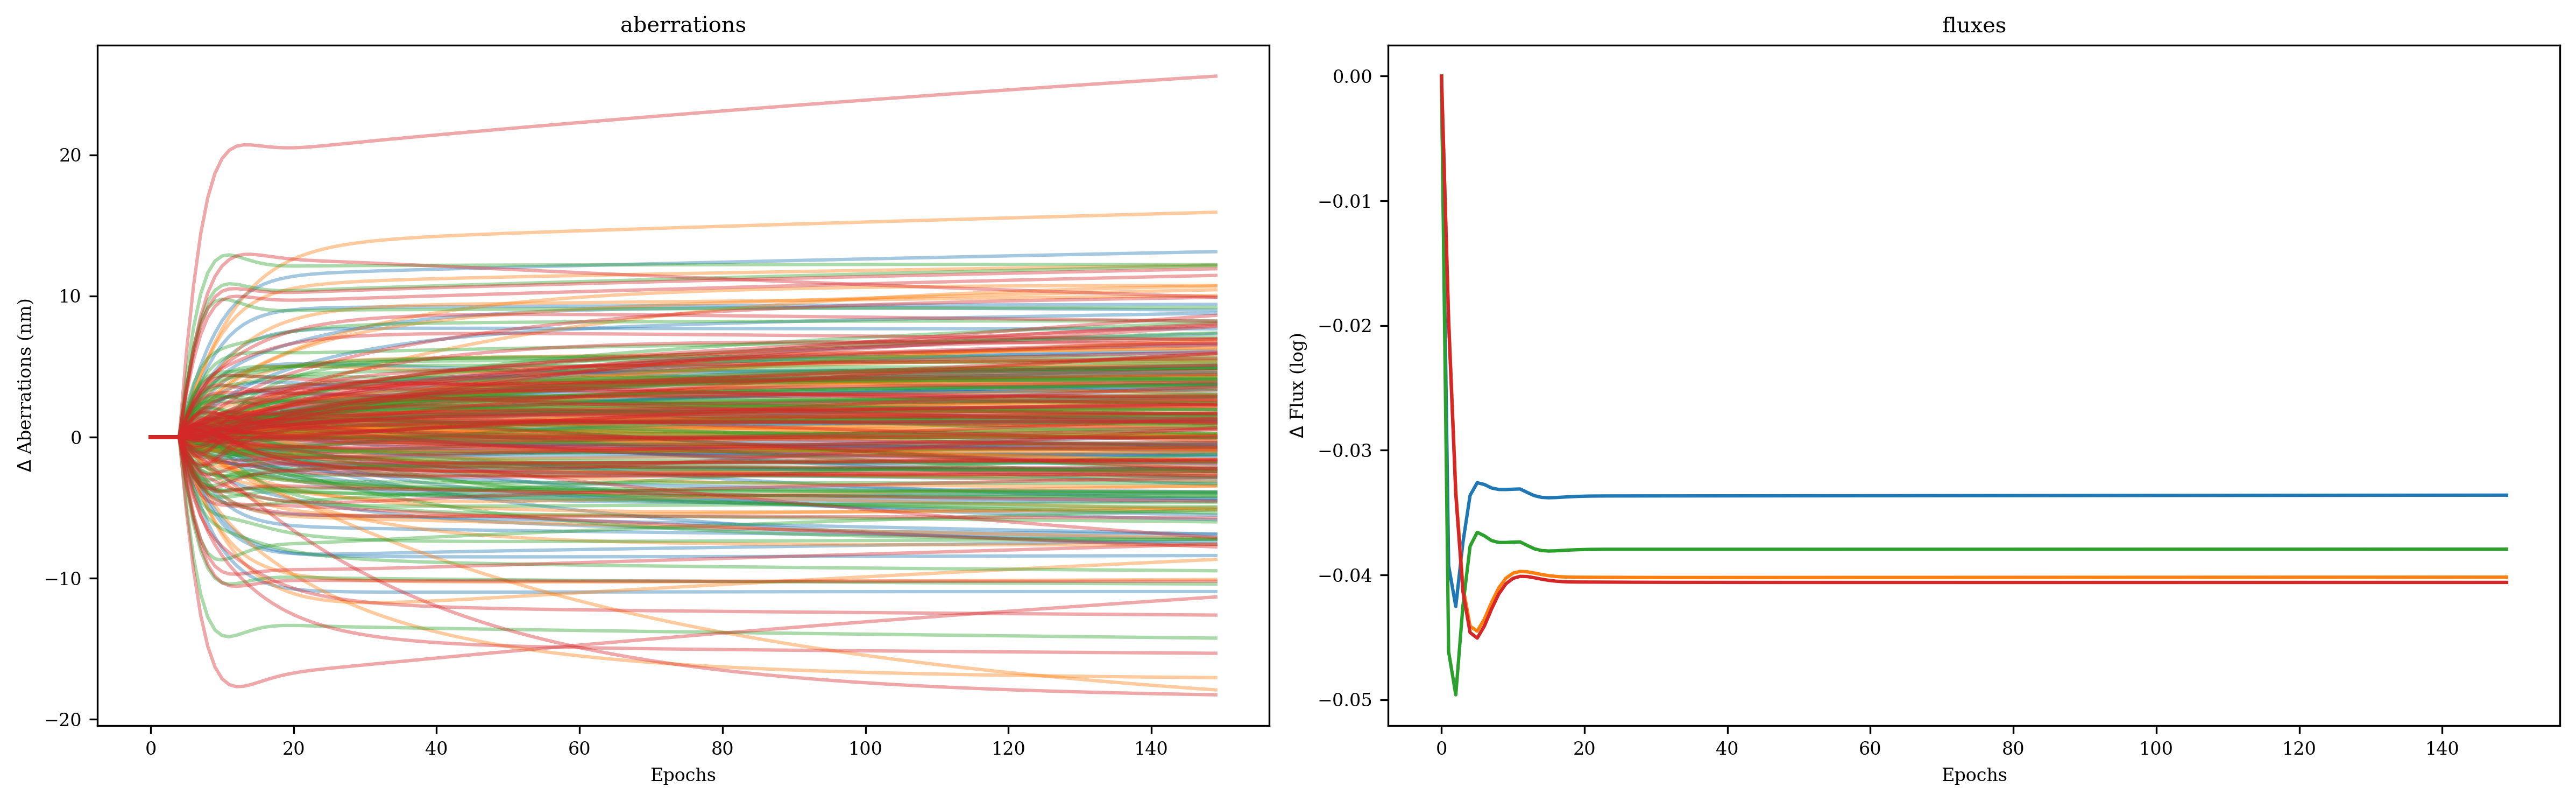

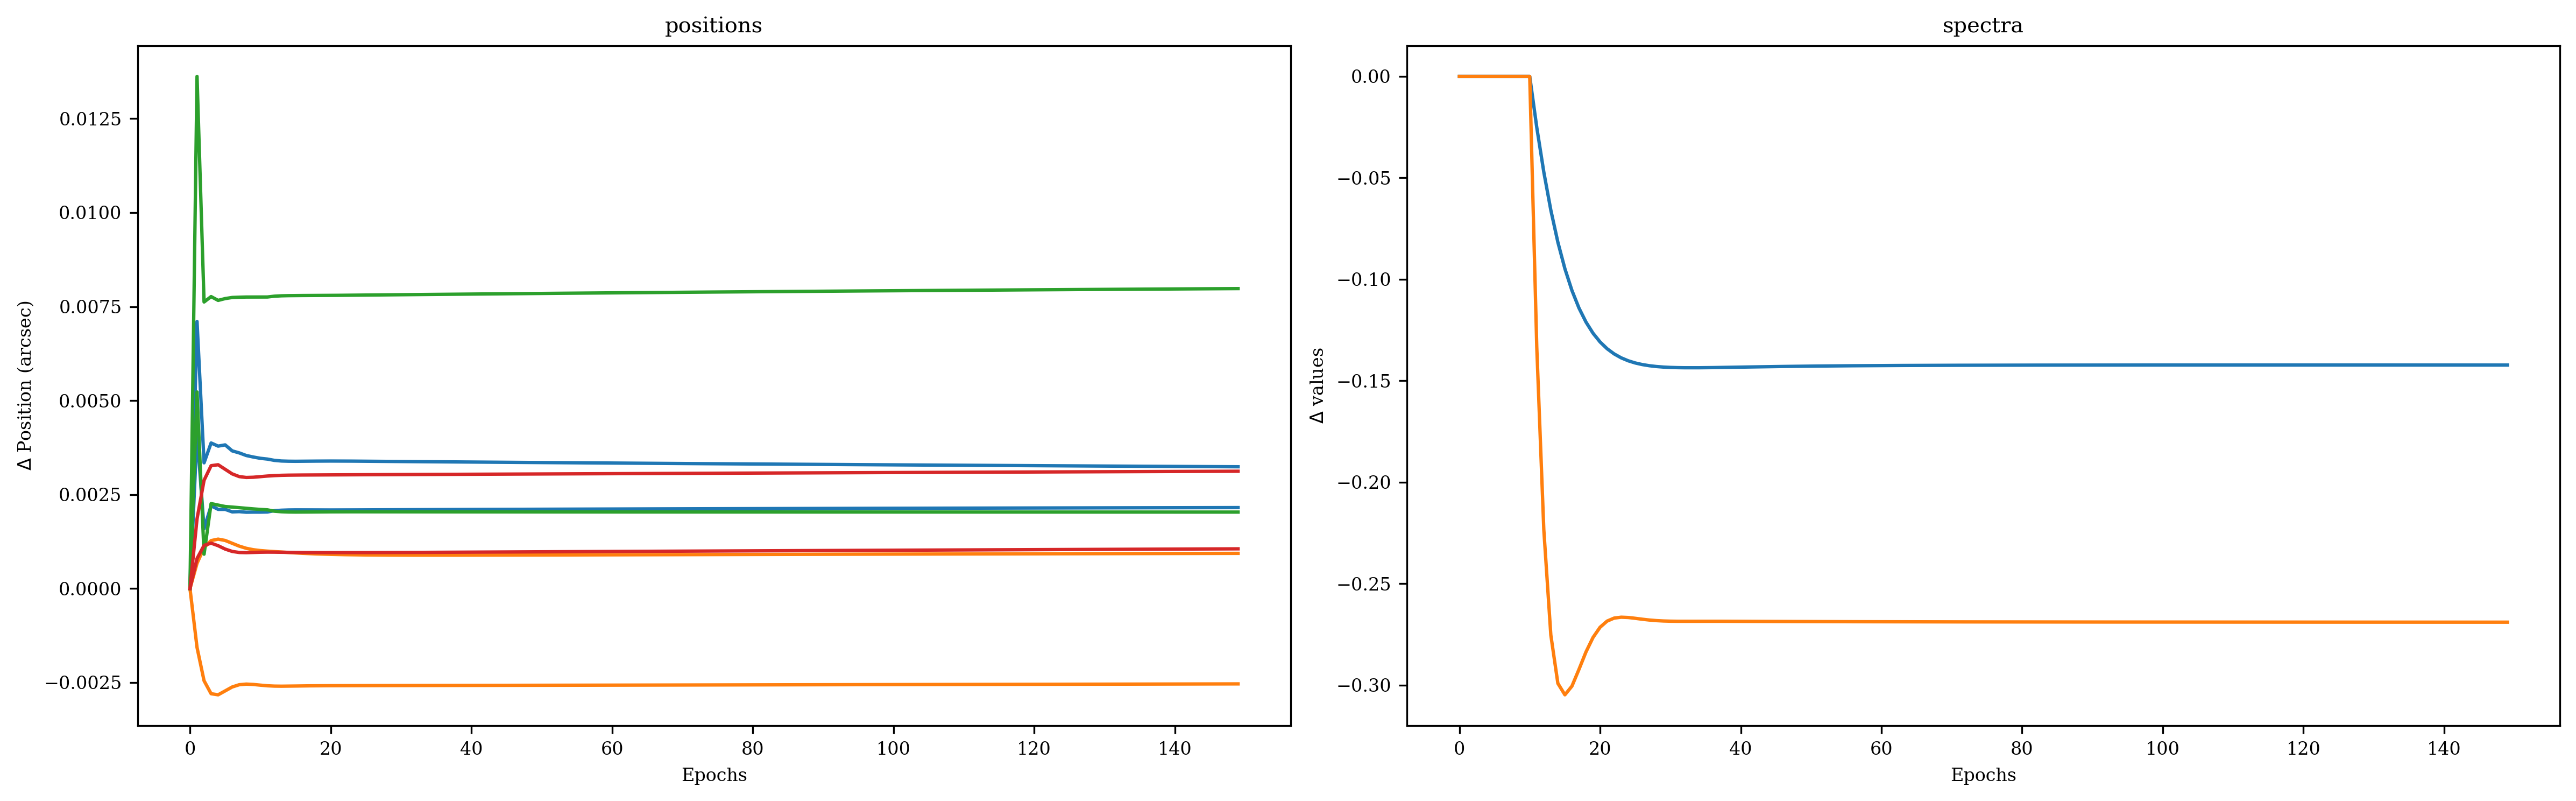

HD 228337


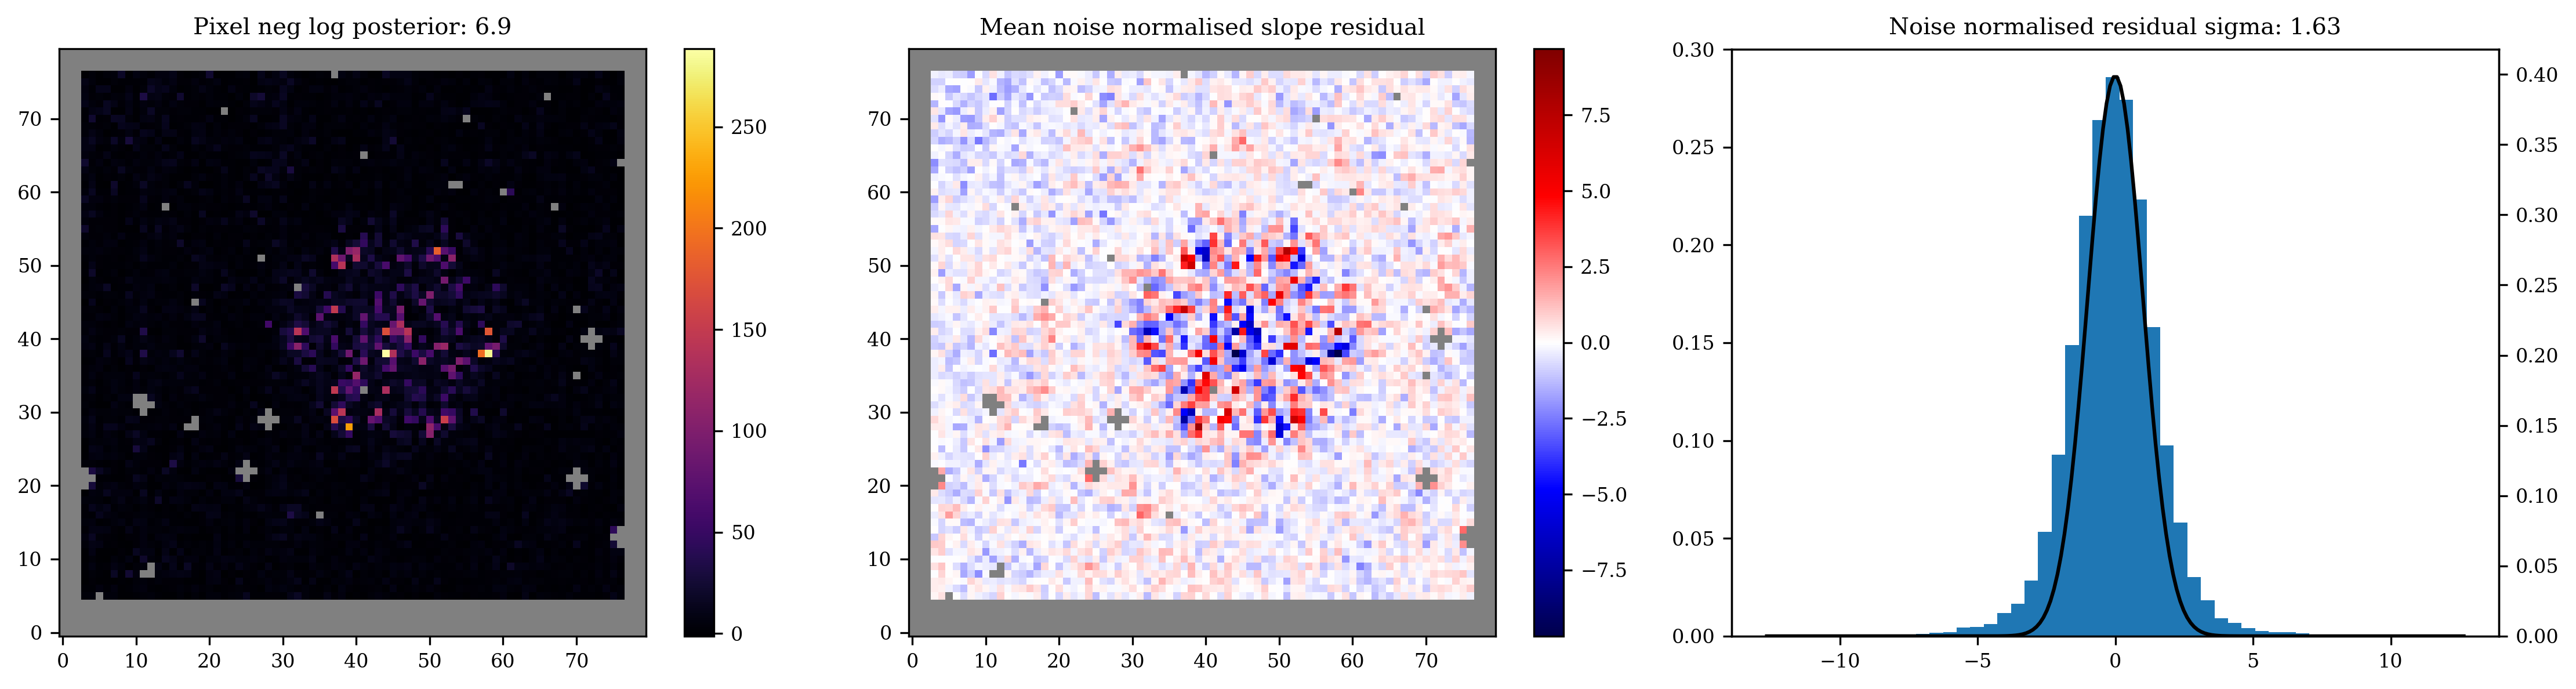

HD 228337


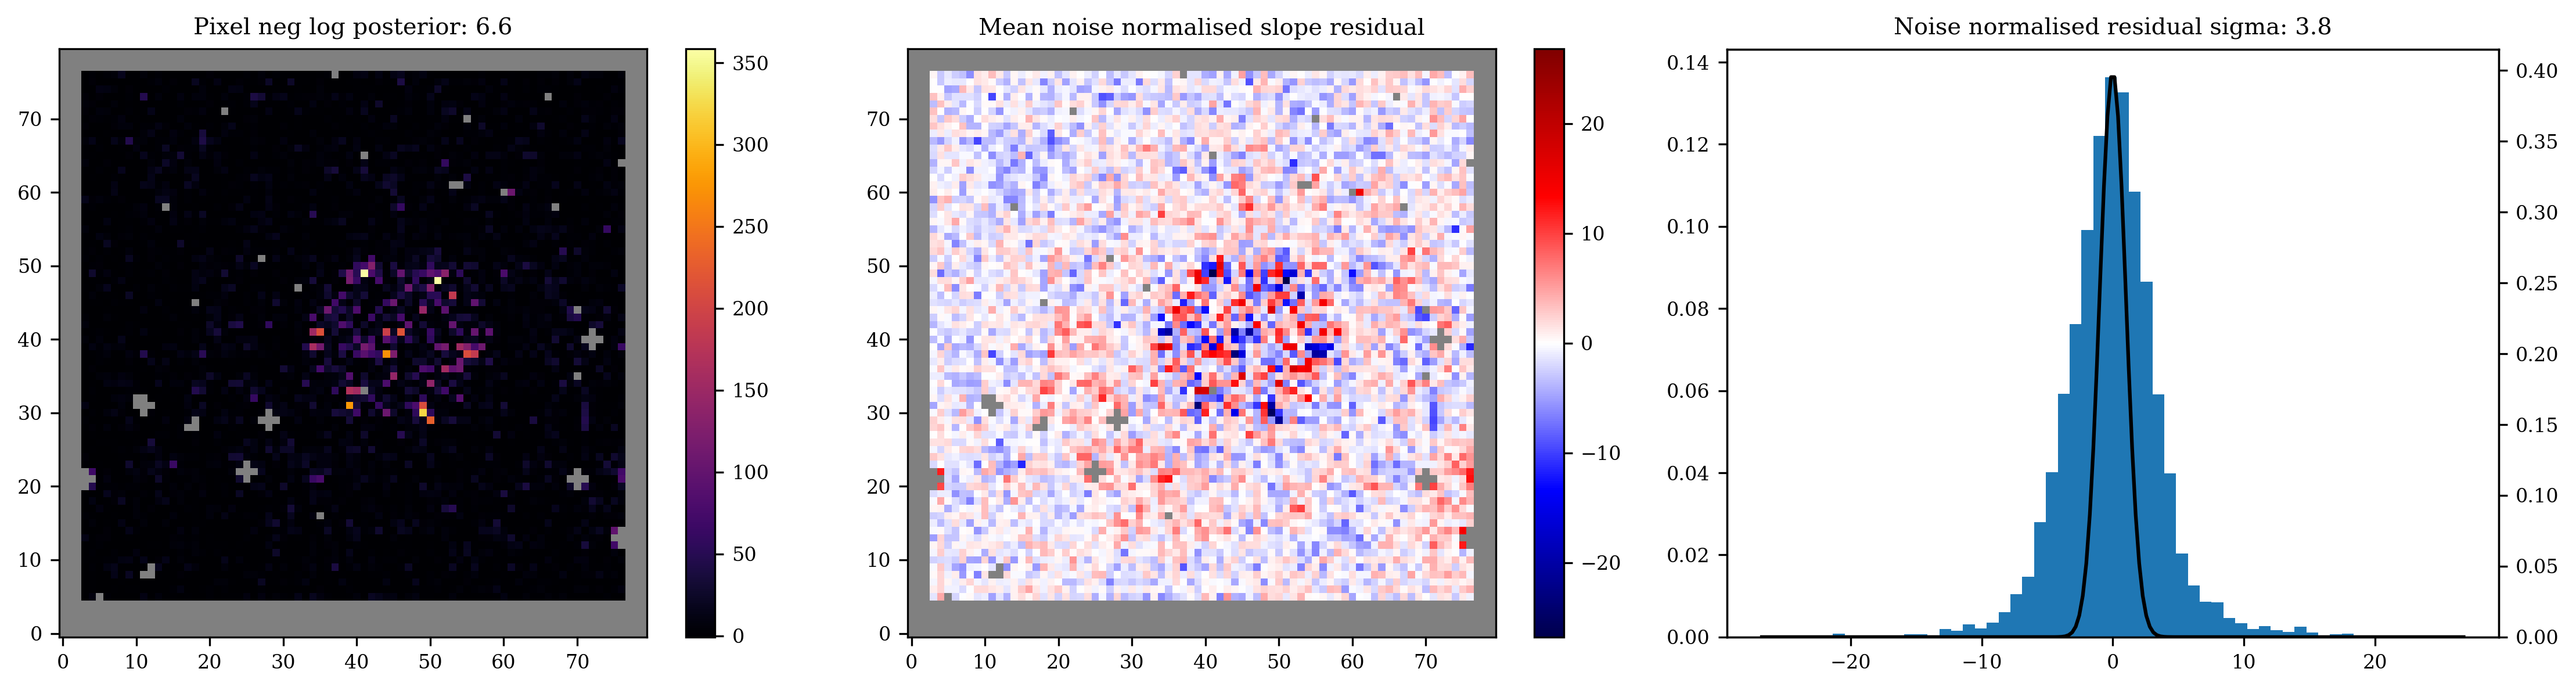

HD 228337


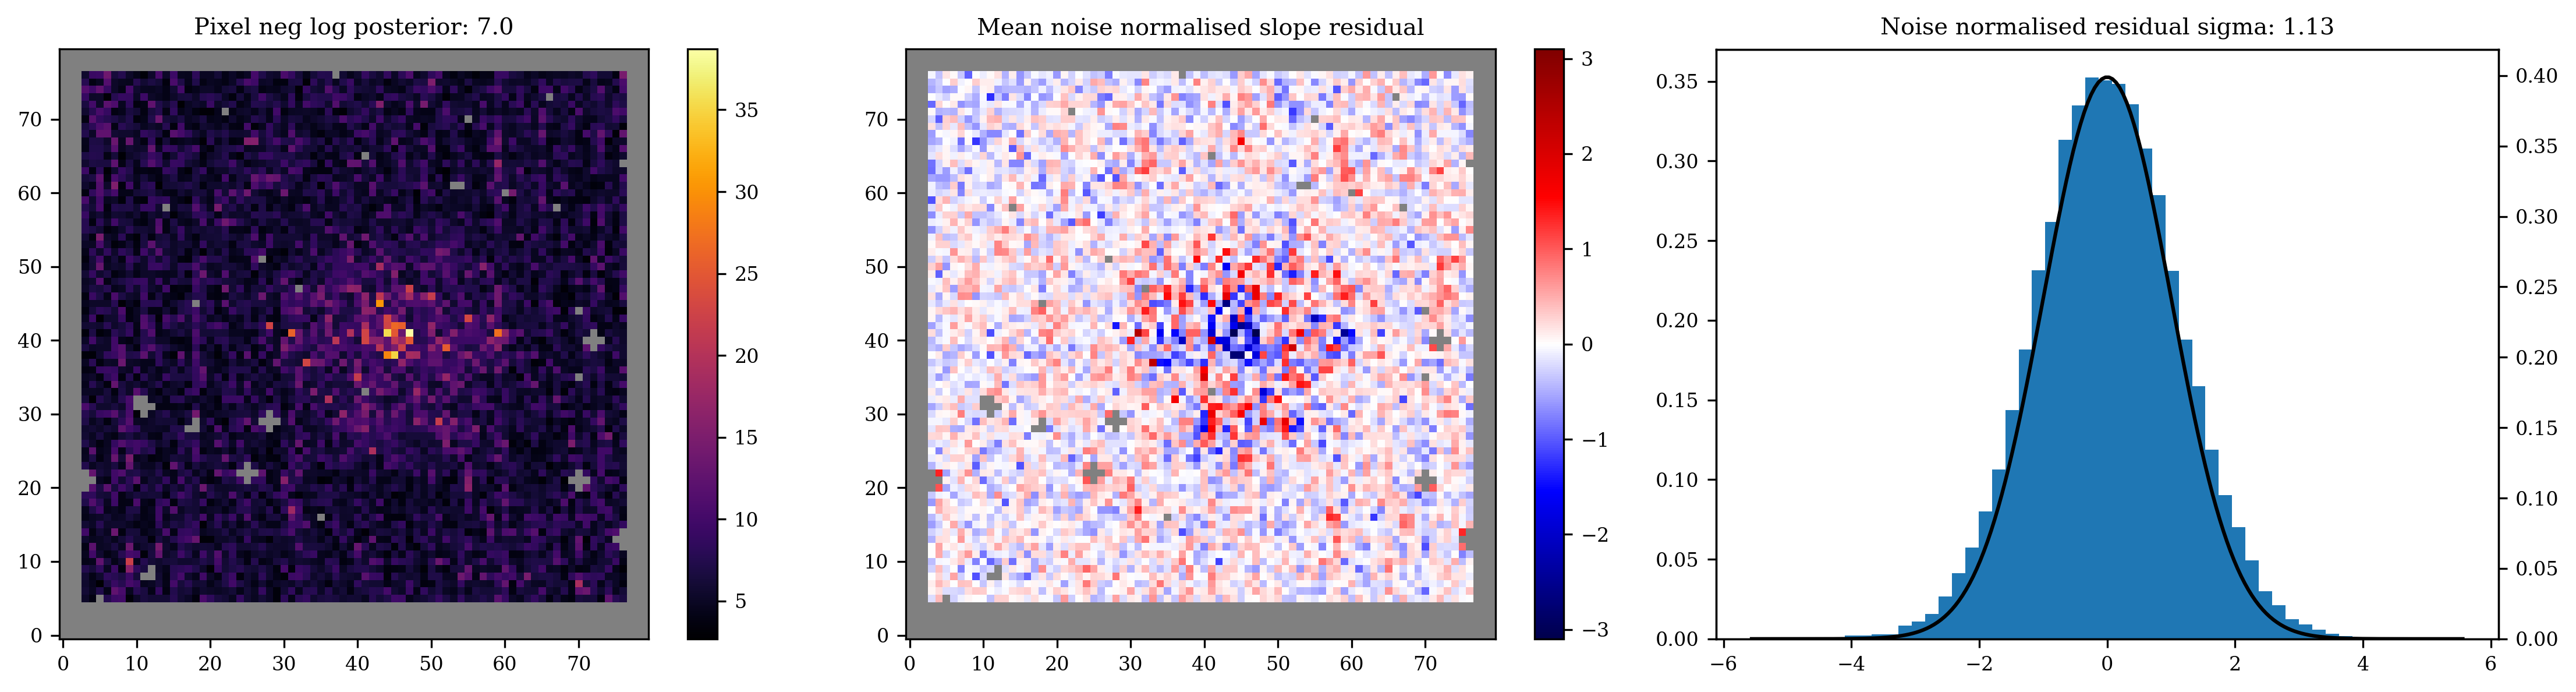

HD 228337


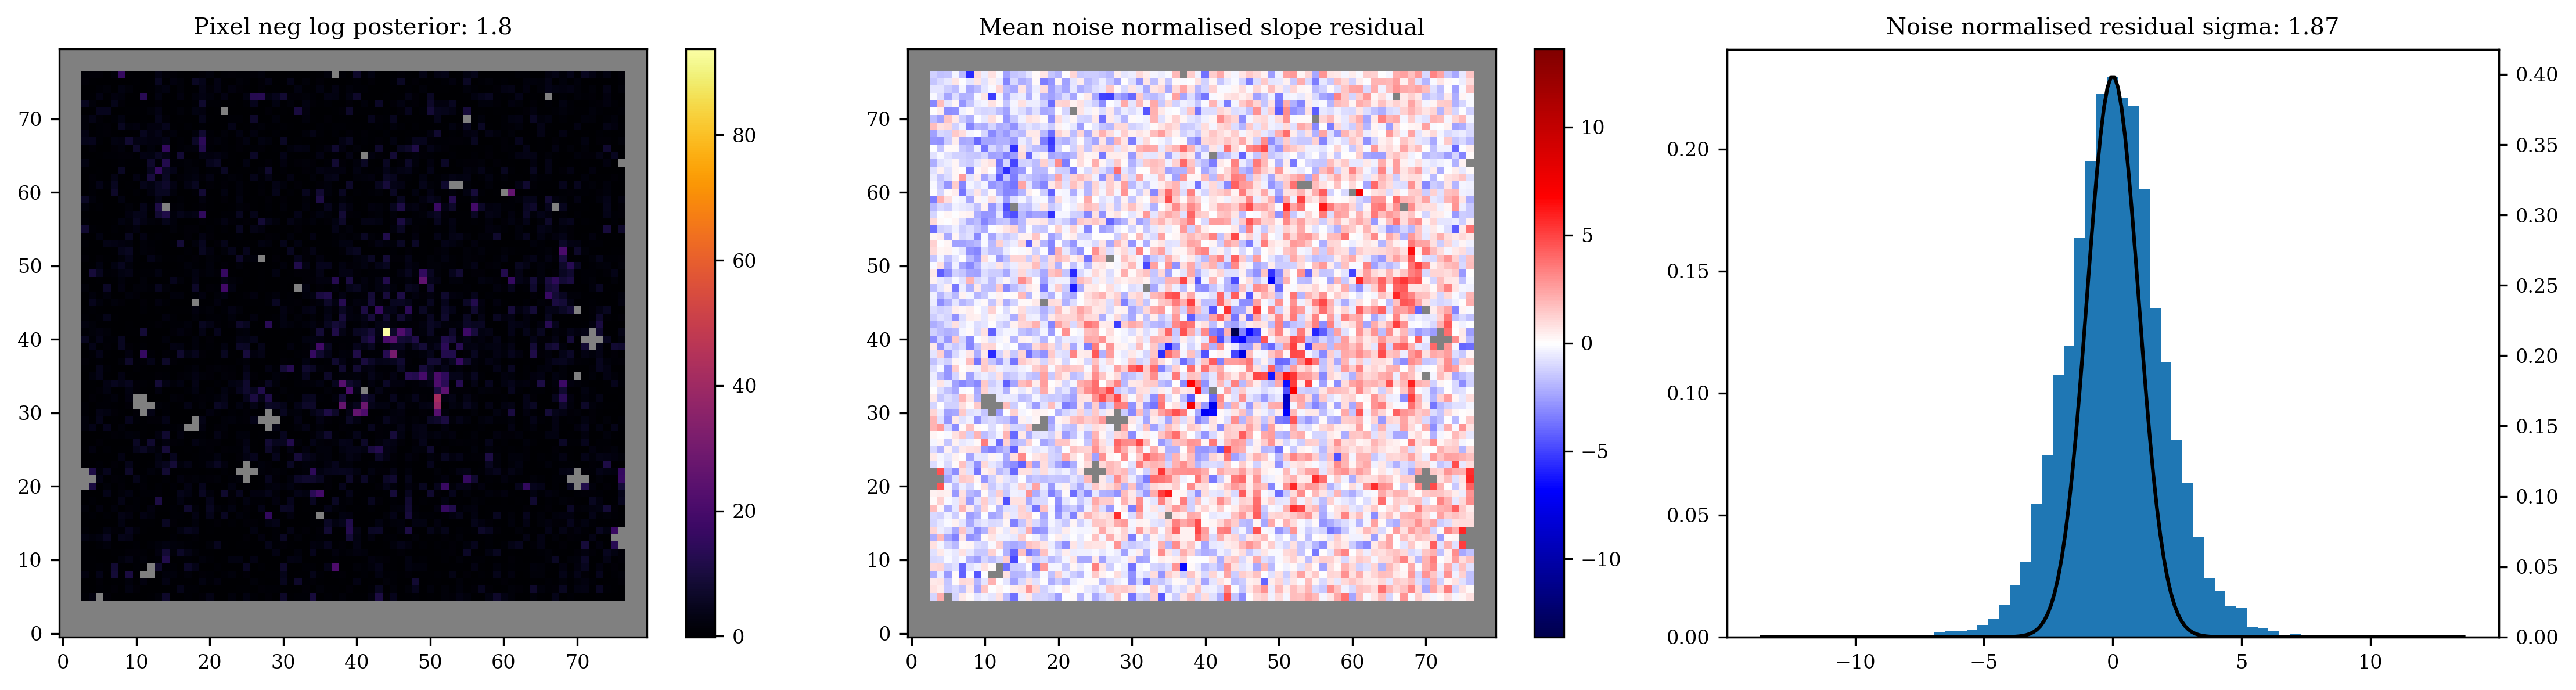

In [ ]:
losses = np.array([v for v in result.losses.values()]).mean(0)

amigo.plotting.plot_losses(losses, start=int(0.8 * n_epoch))
amigo.plotting.plot(result.history)

# for exp in exposures:
for exp in exposures:
    print(exp.star)
    amigo.plotting.summarise_fit(result.model, exp)

In [ ]:
# zdx.experimental.serialise(output_path + "firstbigrun.zdx", result.model.params)

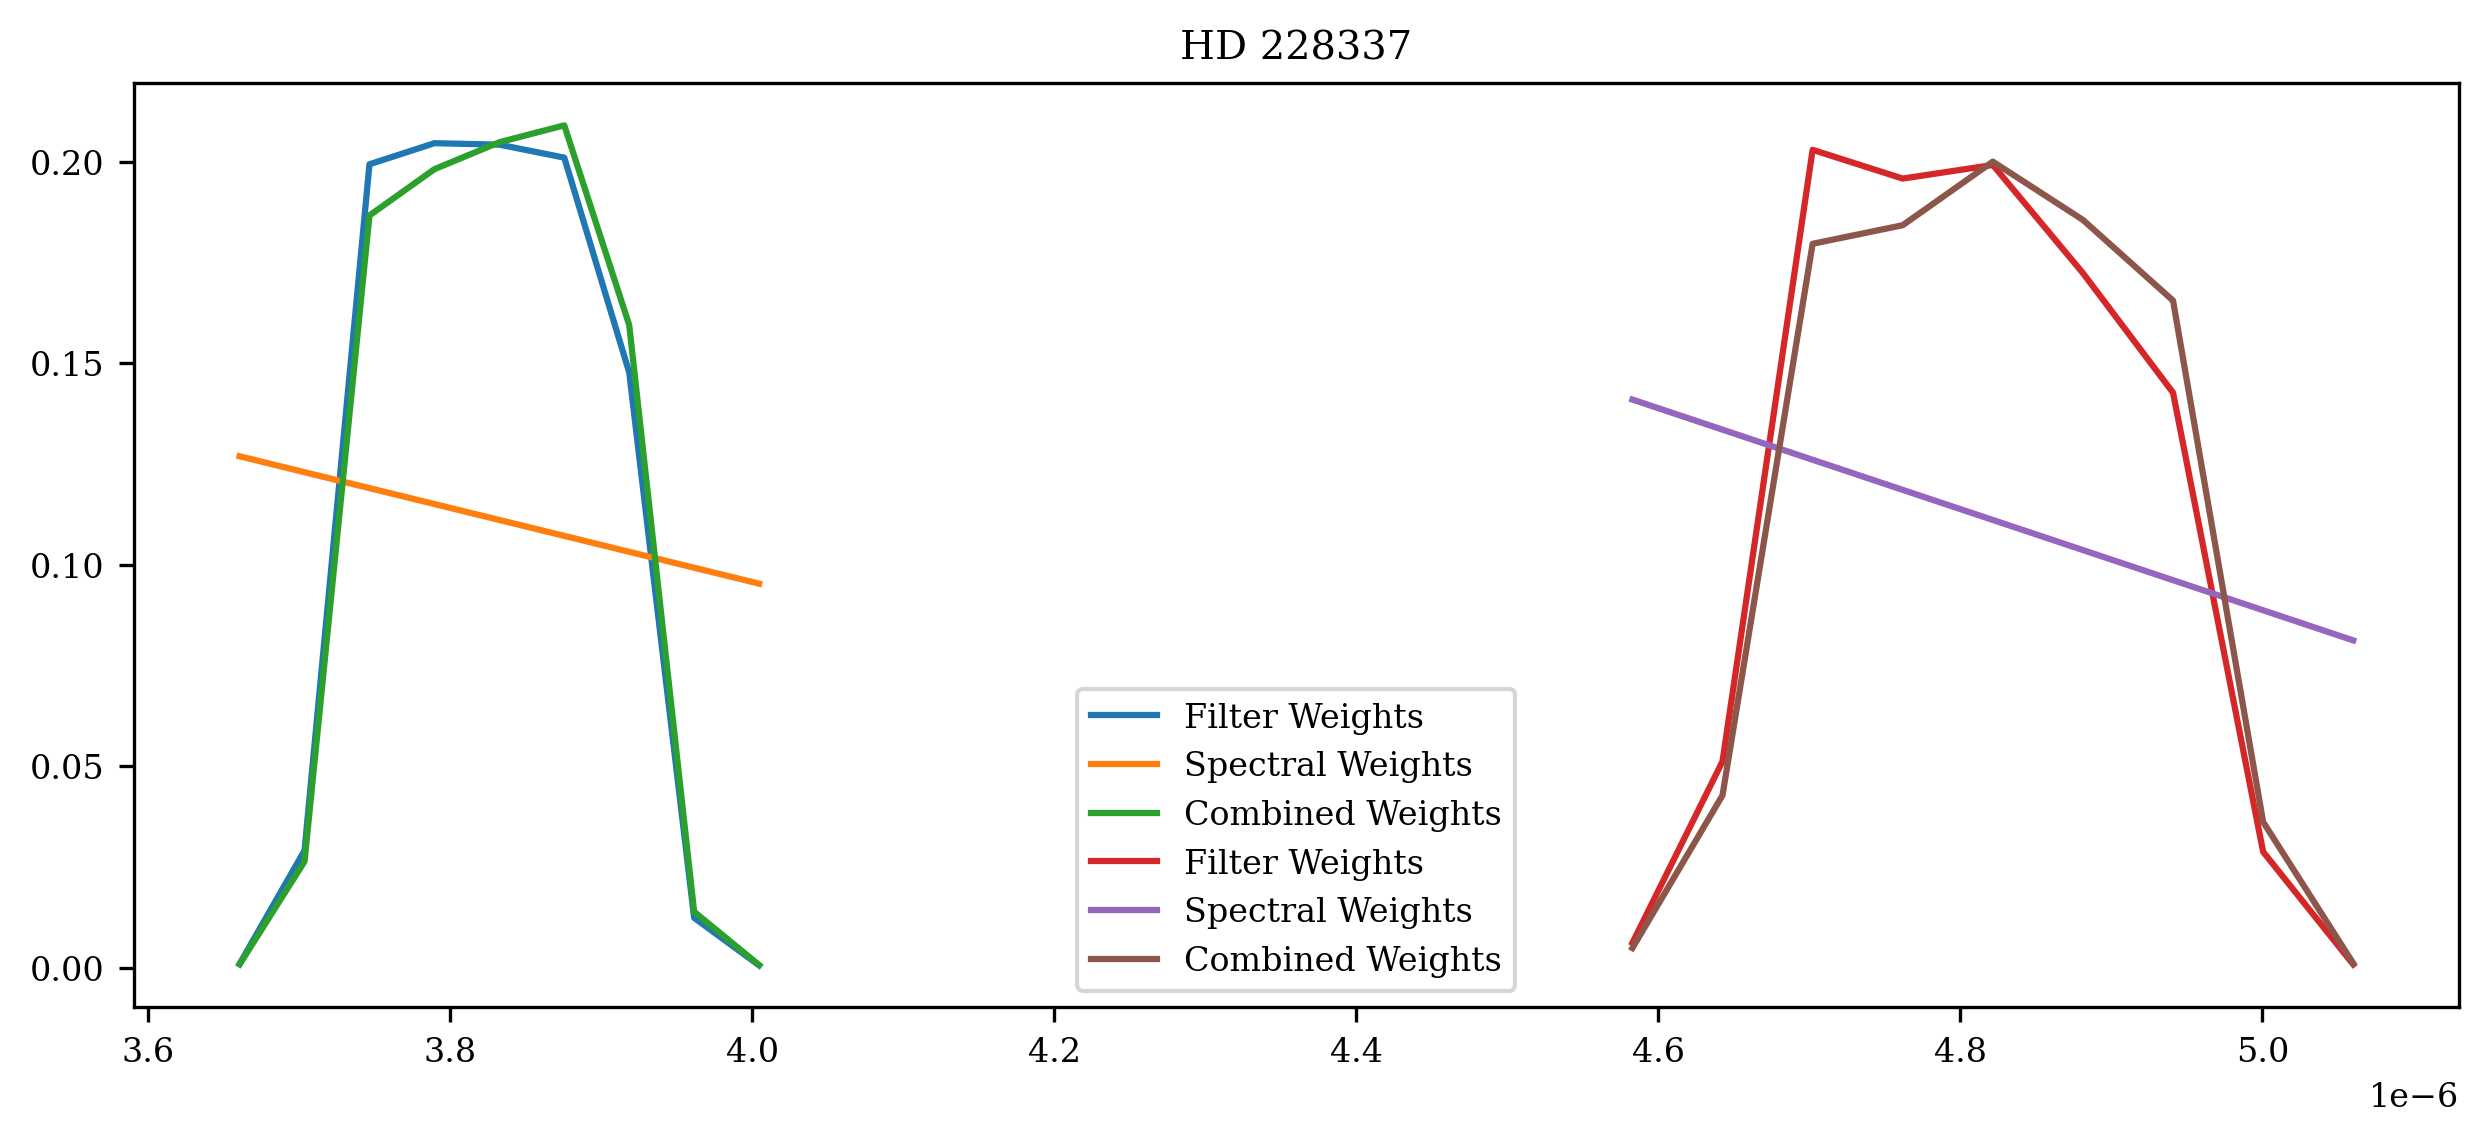

In [ ]:
stars = list(set([exp.star for exp in exposures]))

for targ_star in stars:
    plt.figure(figsize=(10, 4))
    plt.title(f"{targ_star}")
    for key, spec in result.model.spectra.items():
        star, filt = key.split("_")

        if star != targ_star:
            continue

        wavels, filt_weights = model.filters[filt]
        xs = np.linspace(-1, 1, len(wavels), endpoint=True)
        spectra_slopes = 1 + spec * xs
        weights = filt_weights * spectra_slopes  # * wavels

        #
        filt_weights = filt_weights / filt_weights.sum()
        spectra_slopes = spectra_slopes / spectra_slopes.sum()
        weights = weights / weights.sum()

        plt.plot(wavels, weights, label="Filter Weights")
        plt.plot(wavels, spectra_slopes, label="Spectral Weights")
        plt.plot(wavels, filt_weights, label="Combined Weights")

    plt.legend()
    plt.show()

In [ ]:
import equinox as eqx
import optimistix as optx
from amigo.core_models import ModelParams


def get_proj_mat(fmat):
    """Get the projection matrix for a Fisher matrix"""
    eig_vals, eig_vecs = np.linalg.eig(-fmat)
    return (eig_vals.real**-0.5)[:, None] * eig_vecs.real.T


proj_mats = jtu.map(get_proj_mat, trainer.fishers)


@eqx.filter_jit
def fun(params, args):
    model, exp, model_params, proj_mats, shapes = args

    # Project and add the parameters
    proj_params = jtu.map(lambda x, y: np.dot(x, y), proj_mats, params)
    model_params = jtu.map(lambda x, y: x + y, model_params, proj_params)
    model_params = jtu.map(lambda x, y: x.reshape(y), model_params, shapes)
    model = model_params.inject(model)

    # Return the loss
    return -np.nanmean(exp.mv_zscore(model))


params = ["amplitudes", "phases", "fluxes", "spectra"]
final_model = result.model

args_out = {}
sols_out = {}
for exp in exposures:
    opt_params = {}
    fishers = {}
    shapes = {}
    for param in params:
        key = exp.map_param(param)
        shapes[key] = final_model.get(key).shape
        opt_params[key] = final_model.get(key).flatten()
        fishers[key] = trainer.fishers[f"{exp.key}.{param}"]

    shapes = ModelParams(shapes)
    model_params = ModelParams(opt_params)
    initial_params = jtu.map(lambda x: np.zeros_like(x), model_params)
    proj_mats = jtu.map(get_proj_mat, ModelParams(fishers))
    proj_mats = jtu.map(lambda x: np.where(np.isnan(x) | np.isinf(x), 0, x), proj_mats)

    args = (final_model, exp, model_params, proj_mats, shapes)
    args_out[exp.key] = args

    try:
        print("Initial loss:", fun(initial_params, args))
    except Exception as e:
        print(f"Skipped {exp.key}")
        continue
    solver = optx.BFGS(rtol=1e-6, atol=1e-6)
    sol = optx.minimise(fun, solver, initial_params, args, throw=False, max_steps=2048)
    sols_out[exp.key] = sol

    print("Final loss:", fun(sol.value, args))
    print(sol.stats["num_steps"], sol.state.num_accepted_steps)
    print(optx.RESULTS[sol.result])
    print()

In [ ]:
spectra = {}
for key, args in args_out.items():
    proj_mats = args[3]
    proj_params = jtu.map(lambda x, y: np.dot(x, y), proj_mats, sols_out[key].value)
    model_params = jtu.map(lambda x, y: x + y, args[2], proj_params)
    model_params = jtu.map(lambda x, y: x.reshape(y), model_params, args[4])
    final_model = model_params.inject(final_model)

    # Spectra is joint-fit so we take the mean
    exp = args[1]
    spec = model_params.params[exp.map_param("spectra")]
    spec_key = exp.get_key("spectra")
    if spec_key not in spectra:
        spectra[spec_key] = [spec]
    else:
        spectra[spec_key].append(spec)

spectra = jtu.map(
    lambda x: np.array(x).mean(), spectra, is_leaf=lambda x: isinstance(x, list)
)
final_model = final_model.set("spectra", spectra)

final_state = {}
for key, values in result.state.items():
    final_state[key] = final_model.get(key)

In [ ]:
for filt in ["F380M", "F430M", "F480M"]:
    for exp in exposures:
        if exp.filter == filt:
            exp_type = "Calibrator" if exp.calibrator else "Science"
            print(exp.filter, exp_type, exp.star, exp.ngroups)
            amigo.plotting.summarise_fit(final_model, exp)

In [ ]:
import jax.tree as jtu
from tqdm.notebook import tqdm
from amigo.fisher import FIM


fmats = {}
for exp in tqdm(exposures):
    loglike_fn = lambda model: -np.nansum(exp.loglike(model))
    params = [exp.map_param("amplitudes"), exp.map_param("phases")]
    fmat = FIM(final_model, params, loglike_fn, reduce_ram=True, batch_size=20)
    fmats[exp.get_key("phases")] = fmat

  0%|          | 0/8 [00:00<?, ?it/s]

NameError: name 'log_likelihood' is not defined

In [ ]:
full_covs = jtu.map(lambda x: np.linalg.inv(x), fmats)

n = model.vis_model.n_basis
amp_covs = jtu.map(lambda x: x[:n, :n], full_covs)
phase_covs = jtu.map(lambda x: x[n:, n:], full_covs)

covs = {
    "amplitudes": amp_covs,
    "phases": phase_covs,
}

plt.figure(figsize=(20, 10))
for i, key in enumerate(amp_covs):
    if i > 5:
        break

    if i < 3:
        param = "amplitude"
        cov = amp_covs[key]
    else:
        param = "phase"
        cov = amp_covs[key]
    plt.subplot(2, 3, i + 1)
    plt.title(f"{param} Covariance")
    v = np.nanmax(np.abs(cov))
    plt.imshow(cov, seismic, vmin=-v, vmax=v)
    # plt.imshow(np.log10(np.abs(cov)), inferno)
    plt.colorbar()
plt.show()

In [ ]:
fit_outputs = {
    "n_basis": final_model.vis_model.n_basis,
}

for exp in exposures:
    get_fn = lambda param: final_model.get(exp.map_param(param))
    fit_outputs[exp.key] = {
        "star": exp.star,
        "calibrator": exp.calibrator,
        "filter": exp.filter,
        "parang": exp.parang,
        "defocus": final_model.get(exp.map_param("defocus")),
        "n_basis": final_model.vis_model.n_basis,
        "fishers": fmats[exp.get_key("phases")],
        "amp_cov": amp_covs[exp.get_key("phases")],
        "phase_cov": phase_covs[exp.get_key("phases")],
        **{param: get_fn(param) for param in final_state.keys()},
    }

np.save(f"{file_path}/results/GO1843/fit_outputs", fit_outputs, allow_pickle=True)